# Marketing Campaign Success Prediction
**Assessment Task 3 — Data Analysis Project**

Dataset: Telecommunications company marketing campaign (`TeleCom_Data-1.csv`)

## 1. Problem Formulation

**Context:** A telecommunication company recently launched a
marketing campaign to promote the adoption of their new subscription plan among customers.
Predicting which customers will subscribe to the new plan allows targeted, cost-efficient outreach.

**Business Questions:**
1. Which customer segments (demographic, behavioural, economic) are most responsive to campaigns?
2. What are effective business strategies to increase subscription rate?

**Hypotheses:**
- H1: Customers with a prior successful campaign outcome are significantly more likely to subscribe.
- H2: Low Euribor rates and falling employment variation coincide with higher conversion.
- H3: Cellular contact outperforms telephone contact in conversion rate.

**Target Variable:** is_subscribed — binary (1 = subscribed, 0 = did not subscribe).

## 2. Data Collection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency, pointbiserialr
import statsmodels.api as sm
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Read semicolon-delimited CSV with quoted fields
with open('/content/TeleCom_Data-1.csv', 'r') as f:
    lines = f.readlines()

column_names = [col.strip('"') for col in lines[0].strip().split(';')]
data = [[val.strip('"') for val in line.strip().split(';')] for line in lines[1:]]
# Manual parse handles the non-standard semicolon separator and quoted values

df = pd.DataFrame(data, columns=column_names)
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Loaded 41,180 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


## 3. Data Preprocessing
### 3.1 Renaming Columns for Clarity

In [ ]:
df = df.rename(columns={
    'age': 'age', 'job': 'job_type', 'marital': 'marital_status',
    'education': 'education_level', 'default': 'has_credit_default',
    'housing': 'has_housing_loan', 'loan': 'has_personal_loan',
    'contact': 'contact_method', 'month': 'last_contact_month',
    'day_of_week': 'last_contact_day', 'duration': 'call_duration_sec',
    'campaign': 'num_contacts_current_campaign', 'pdays': 'days_since_last_contact',
    'previous': 'num_previous_contacts', 'poutcome': 'previous_campaign_outcome',
    'emp.var.rate': 'employment_variation_rate', 'cons.price.idx': 'consumer_price_index',
    'cons.conf.idx': 'consumer_confidence_index', 'euribor3m': 'euribor_3_month_rate',
    'nr.employed': 'num_employees', 'y': 'term_deposit_subscribed'
})
# Descriptive names reduce ambiguity in outputs and model interpretation
print('Columns:', df.columns.tolist())

Columns: ['age', 'job_type', 'marital_status', 'education_level', 'has_credit_default', 'has_housing_loan', 'has_personal_loan', 'contact_method', 'last_contact_month', 'last_contact_day', 'call_duration_sec', 'num_contacts_current_campaign', 'days_since_last_contact', 'num_previous_contacts', 'previous_campaign_outcome', 'employment_variation_rate', 'consumer_price_index', 'consumer_confidence_index', 'euribor_3_month_rate', 'num_employees', 'term_deposit_subscribed']


### 3.2 Data Type Conversion

In [ ]:
numeric_columns = ['age', 'num_contacts_current_campaign', 'days_since_last_contact',
                   'num_previous_contacts', 'employment_variation_rate',
                   'consumer_price_index', 'consumer_confidence_index',
                   'euribor_3_month_rate', 'num_employees', 'call_duration_sec']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# errors='coerce' converts unparseable strings to NaN instead of raising an error

df['is_subscribed'] = (df['term_deposit_subscribed'] == 'yes').astype(int)
print(f'Subscription rate: {df["is_subscribed"].mean():.2%}')
print(df[numeric_columns].dtypes)

Subscription rate: 11.26%
age                                int64
num_contacts_current_campaign      int64
days_since_last_contact            int64
num_previous_contacts              int64
employment_variation_rate        float64
consumer_price_index             float64
consumer_confidence_index        float64
euribor_3_month_rate             float64
num_employees                    float64
call_duration_sec                  int64
dtype: object


### 3.3 Handling Unknown Values

In [ ]:
print('Null counts:\n', df.isnull().sum())

cat_cols_check = ['job_type', 'marital_status', 'education_level',
                  'has_credit_default', 'has_housing_loan', 'has_personal_loan']
print("\n'Unknown' counts:")
for col in cat_cols_check:
    n = (df[col] == 'unknown').sum()
    print(f'  {col:<30}: {n:>5,}  ({n/len(df)*100:.1f}%)')
# 'unknown' is retained as a valid category to avoid introducing imputation bias

Null counts:
 age                              0
job_type                         0
marital_status                   0
education_level                  0
has_credit_default               0
has_housing_loan                 0
has_personal_loan                0
contact_method                   0
last_contact_month               0
last_contact_day                 0
call_duration_sec                0
num_contacts_current_campaign    0
days_since_last_contact          0
num_previous_contacts            0
previous_campaign_outcome        0
employment_variation_rate        0
consumer_price_index             0
consumer_confidence_index        0
euribor_3_month_rate             0
num_employees                    0
term_deposit_subscribed          0
is_subscribed                    0
dtype: int64

'Unknown' counts:
  job_type                      :   330  (0.8%)
  marital_status                :    80  (0.2%)
  education_level               : 1,731  (4.2%)
  has_credit_default            : 8,596 

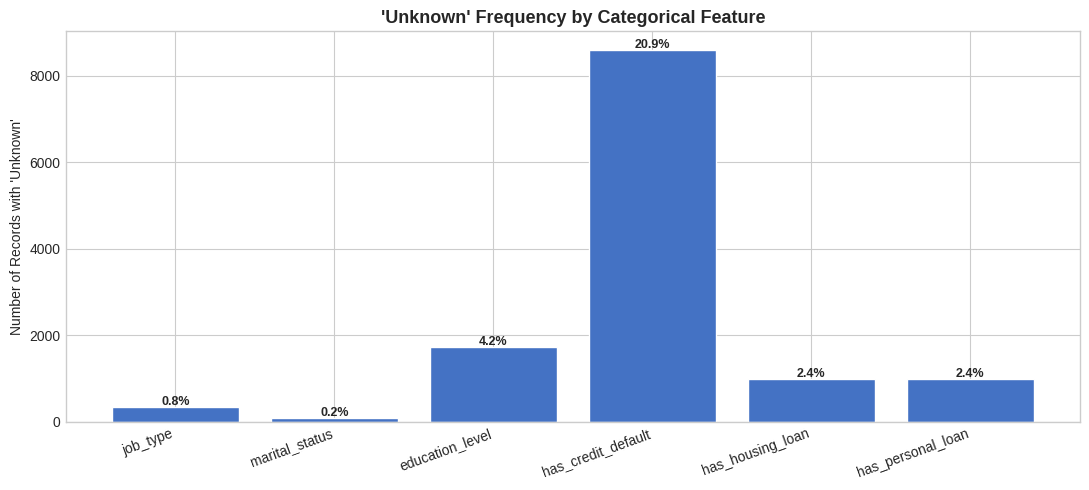

In [ ]:
total_rows = len(df)
unknown_counts = [(df[col] == 'unknown').sum() for col in cat_cols_check]
unknown_pcts   = [n / total_rows * 100 for n in unknown_counts]

plt.figure(figsize=(11, 5))
bars = plt.bar(cat_cols_check, unknown_counts, color='#4472C4', edgecolor='white')
for bar, pct in zip(bars, unknown_pcts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.ylabel("Number of Records with 'Unknown'")
plt.title("'Unknown' Frequency by Categorical Feature", fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()
# has_credit_default has the highest unknown rate (~20%); imputing would risk data leakage

### 3.4 Removing Duplicate Rows

In [ ]:
print(f'Duplicates found: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after dedup: {df.shape}')
# Duplicate rows inflate training signal and distort validation metrics

Duplicates found: 12
Shape after dedup: (41168, 22)


## 4. Exploratory Data Analysis
### 4.1 Summary Statistics

In [ ]:
print('Numeric summary:')
display(df.describe().round(2))
print('\nCategorical summary:')
display(df.describe(include=['object']))

Numeric summary:


,age,call_duration_sec,num_contacts_current_campaign,days_since_last_contact,num_previous_contacts,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3_month_rate,num_employees,is_subscribed
count,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00,41168.00
mean,40.02,258.31,2.57,962.51,0.17,0.08,93.58,-40.50,3.62,5167.05,0.11
std,10.42,259.33,2.77,186.84,0.49,1.57,0.58,4.63,1.73,72.23,0.32
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60,0.00
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10,0.00
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00,0.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10,0.00
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10,1.00



Categorical summary:


,job_type,marital_status,education_level,has_credit_default,has_housing_loan,has_personal_loan,contact_method,last_contact_month,last_contact_day,previous_campaign_outcome,term_deposit_subscribed
count,41168,41168,41168,41168,41168,41168,41168,41168,41168,41168,41168
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24914,12162,32570,21566,33931,26131,13763,8617,35547,36531


### 4.2 Handling Outliers

In [ ]:
# IQR-based outlier detection
numerical_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
                  if c != 'is_subscribed']

print(f"  {'Column':<35} {'Outliers':>8}  {'%':>6}")
print('-' * 55)
for col in numerical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<35} {n_out:>8,}  {n_out/len(df)*100:>5.2f}%')
# Outliers are retained — tree-based models are robust and extreme values carry predictive signal

  Column                              Outliers       %
-------------------------------------------------------
  age                                      467   1.13%
  call_duration_sec                      2,963   7.20%
  num_contacts_current_campaign          2,406   5.84%
  days_since_last_contact                1,513   3.68%
  num_previous_contacts                  5,621  13.65%
  employment_variation_rate                  0   0.00%
  consumer_price_index                       0   0.00%
  consumer_confidence_index                446   1.08%
  euribor_3_month_rate                       0   0.00%
  num_employees                              0   0.00%


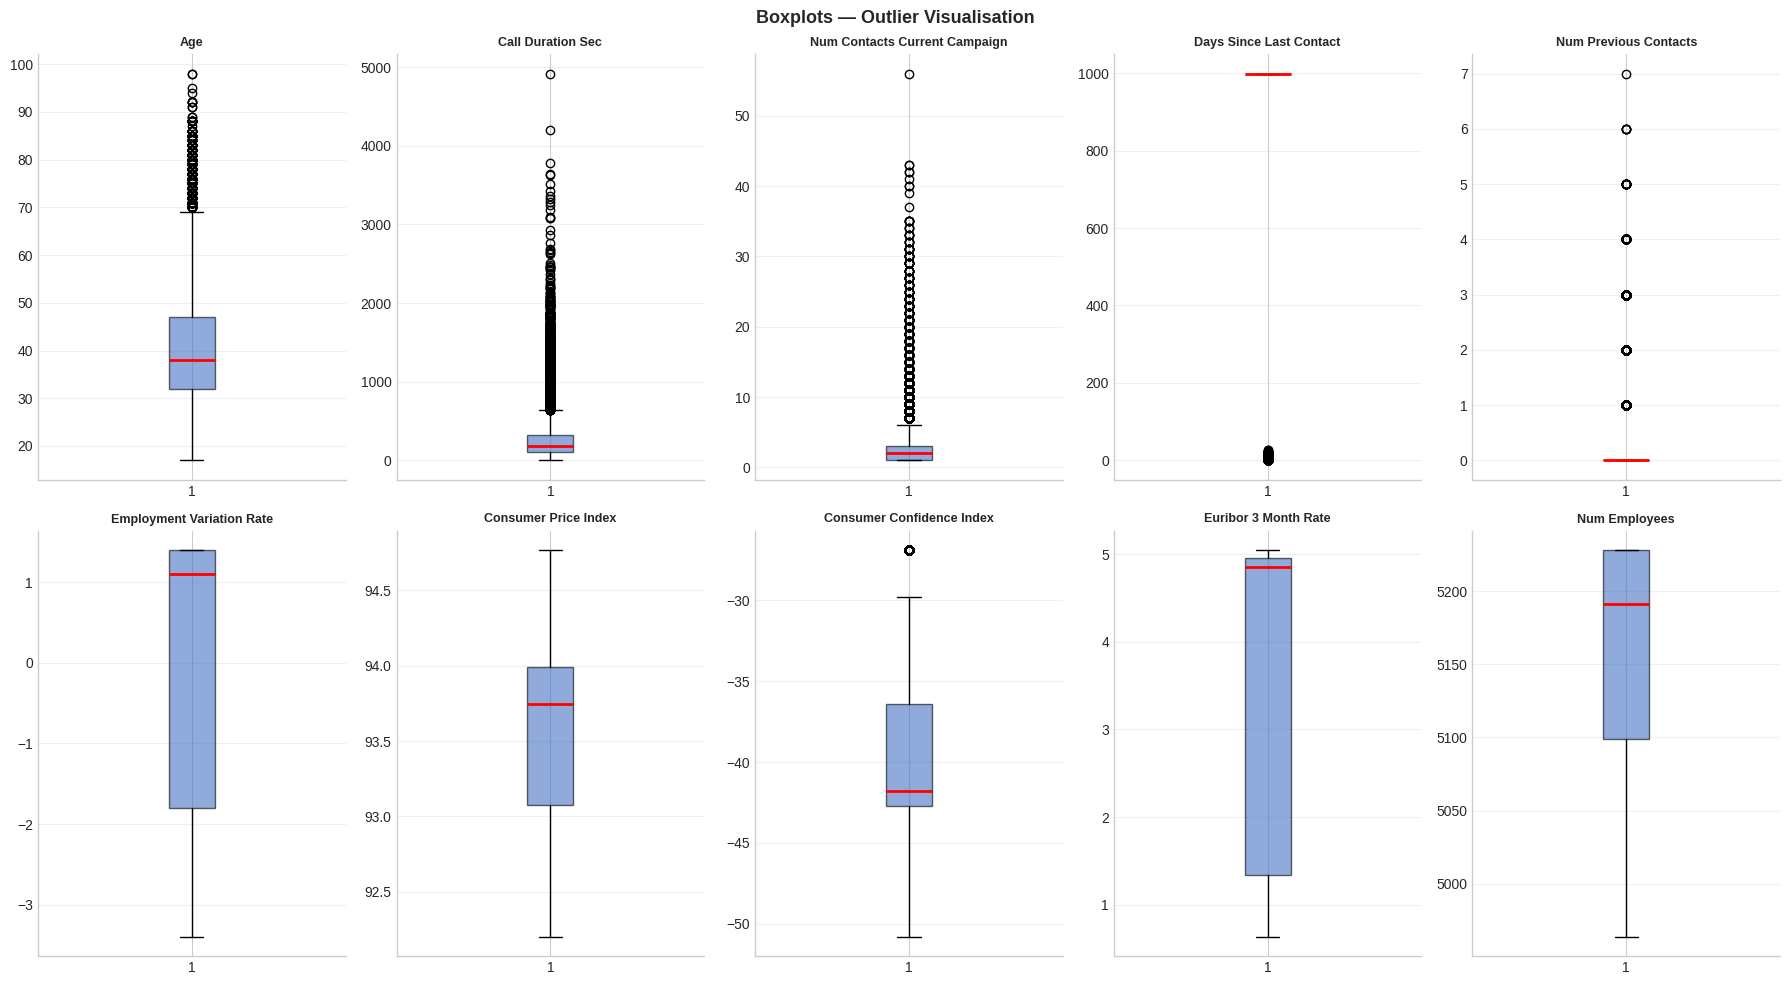

In [ ]:
n = len(numerical_cols)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4472C4', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Boxplots — Outlier Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.3 Categorical Variable Distributions

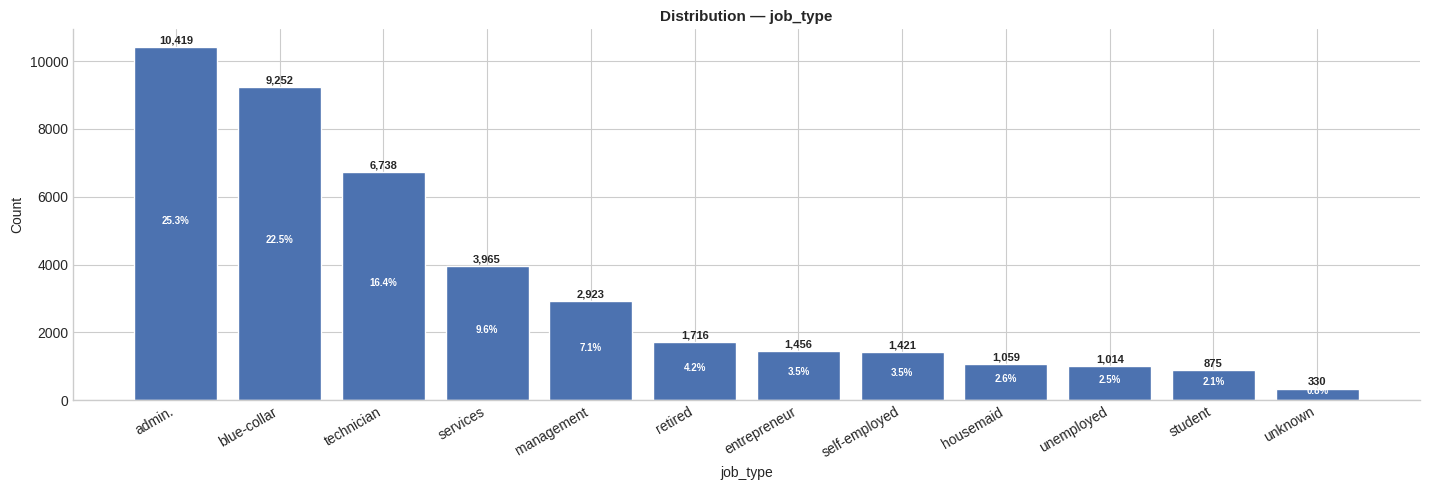

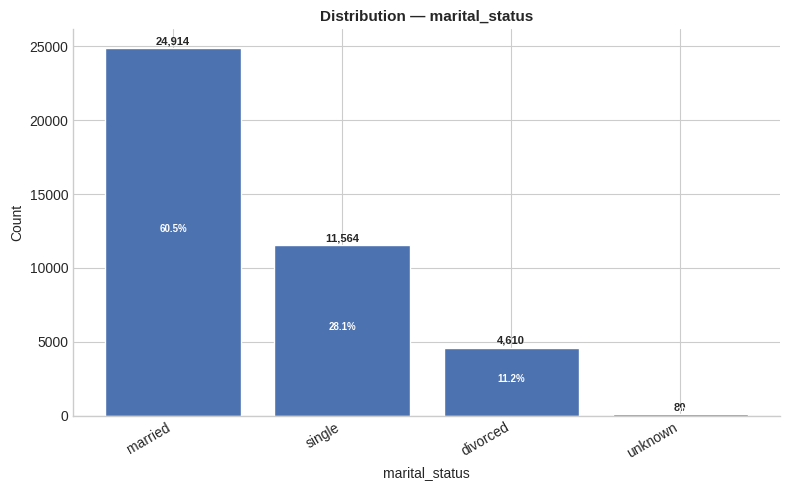

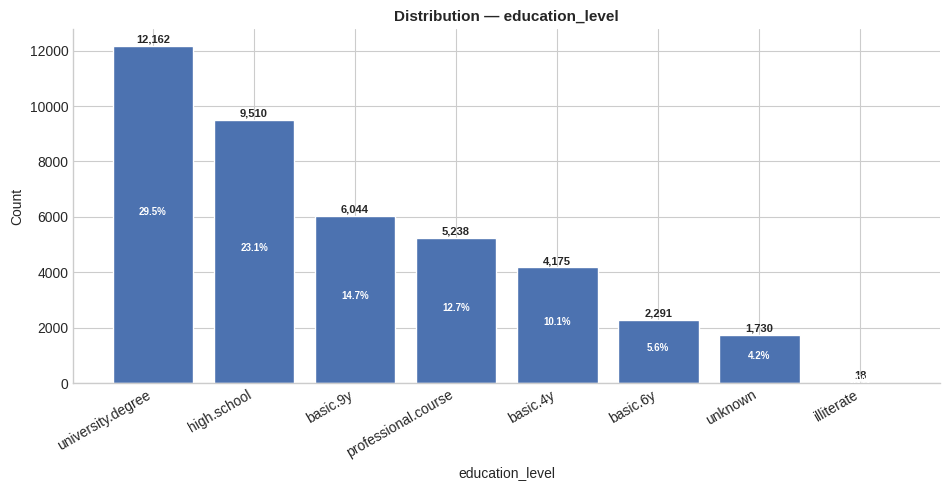

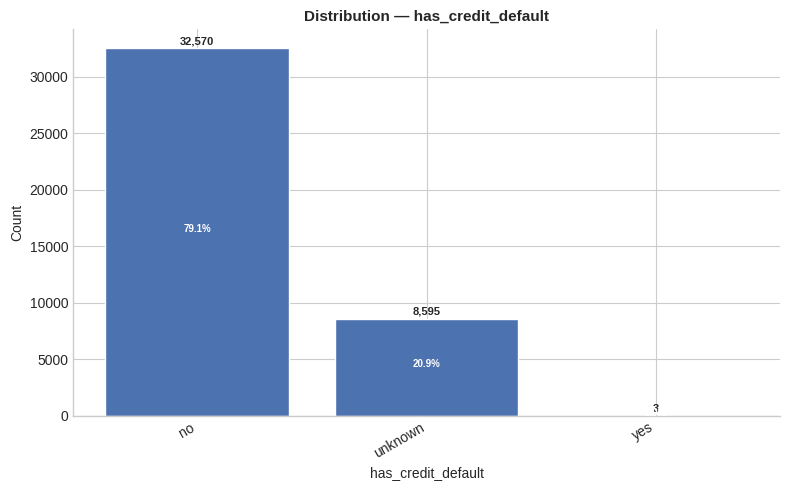

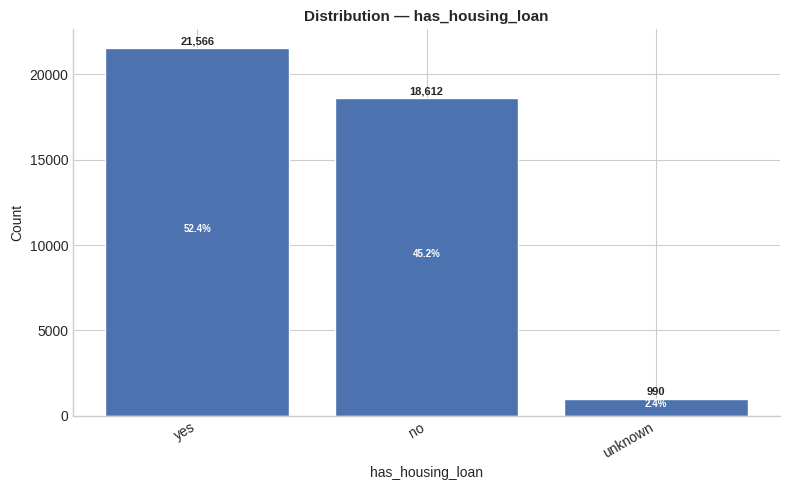

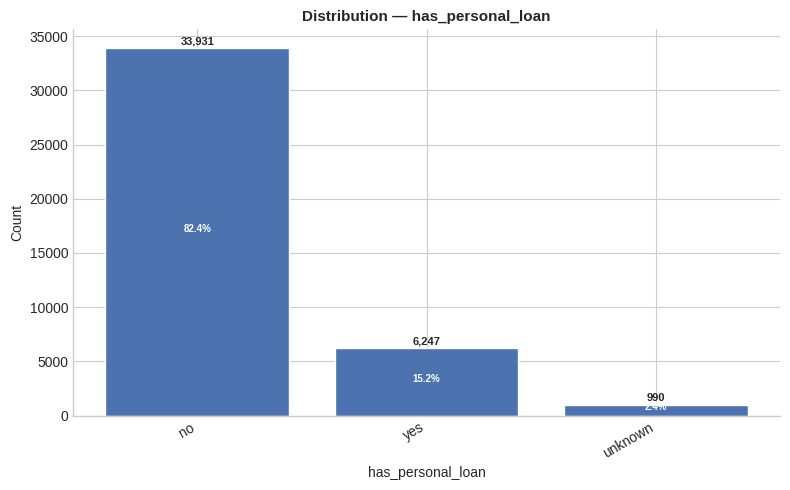

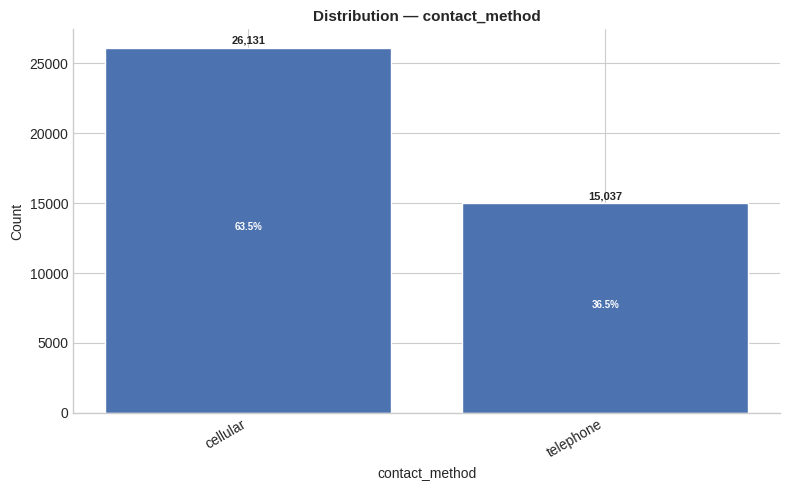

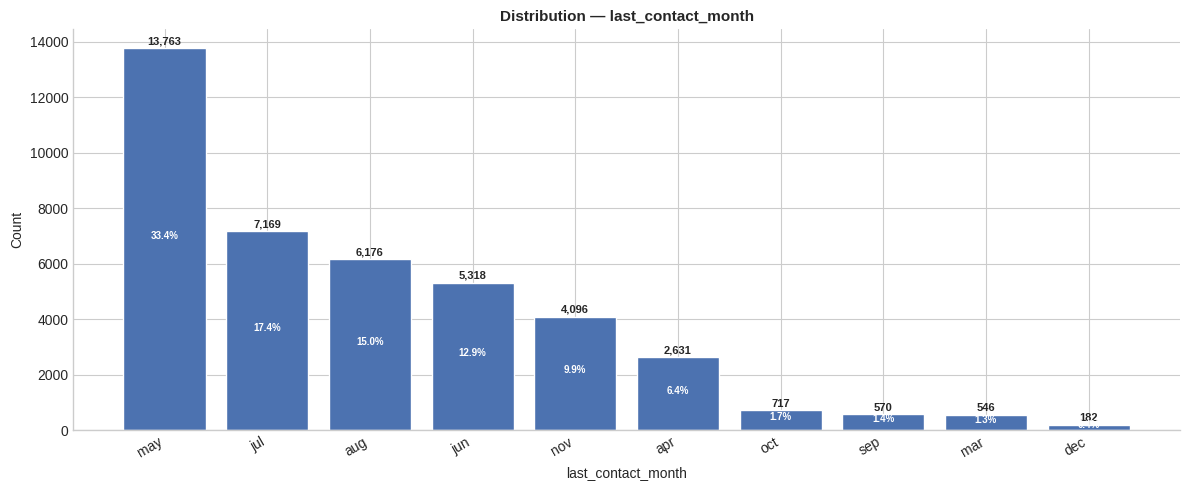

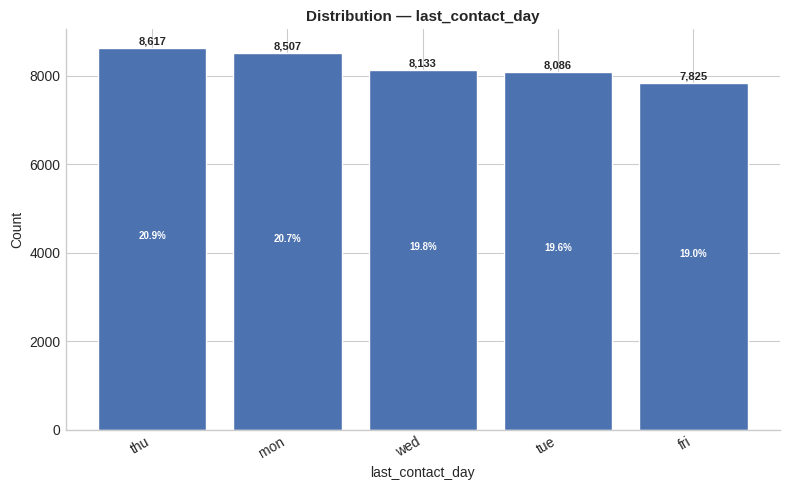

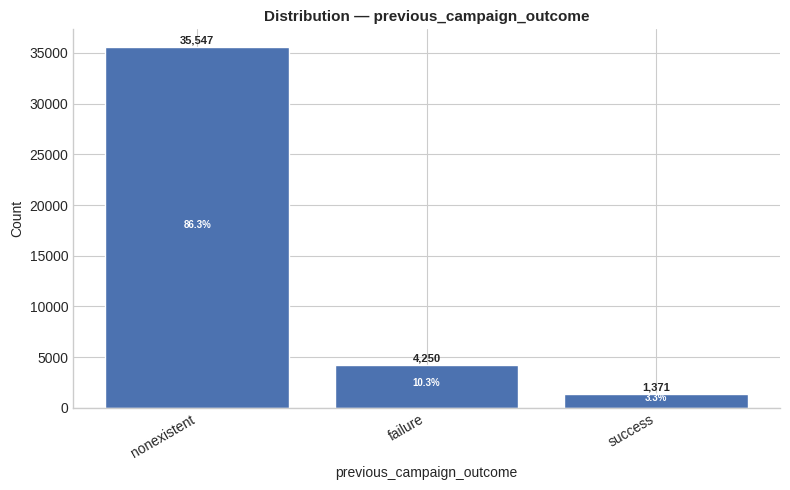

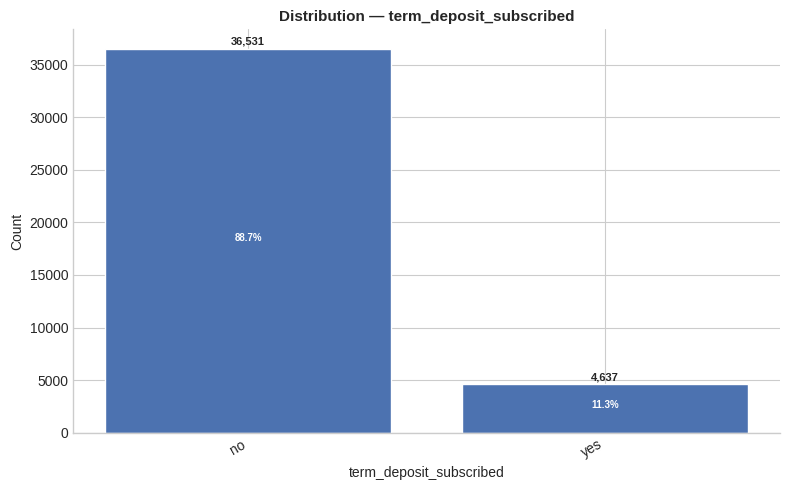

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    vc = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(max(8, len(vc)*1.2), 5))
    bars = ax.bar(vc.index.astype(str), vc.values, color='#4C72B0', edgecolor='white')

    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + vc.max()*0.01,
                f'{val:,}', ha='center', fontsize=8, fontweight='bold')
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                f'{pct:.1f}%', ha='center', fontsize=7, color='white', fontweight='bold')

    ax.set_title(f'Distribution — {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### 4.4 Numeric Variable Distributions

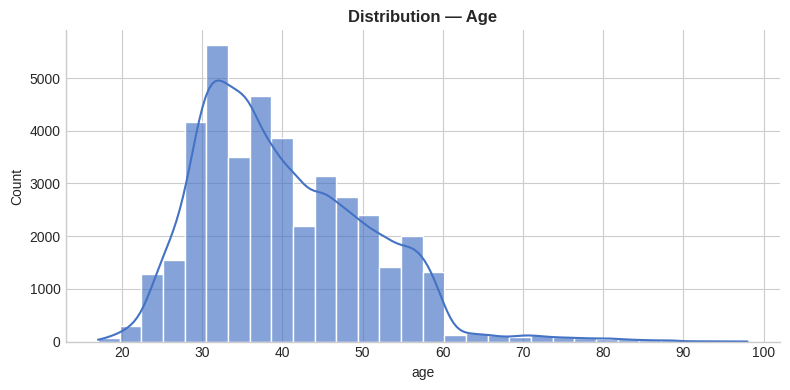

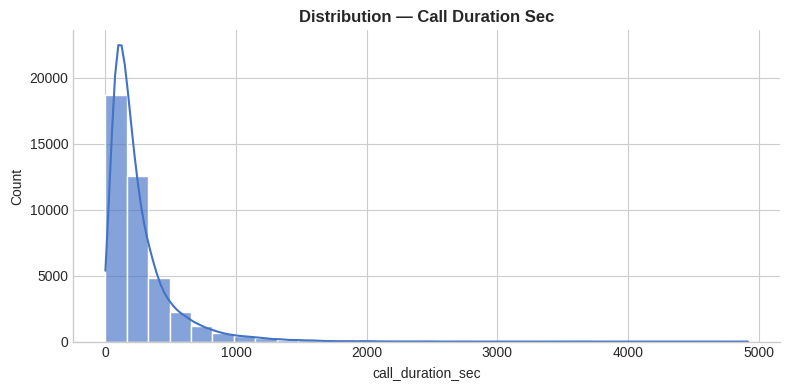

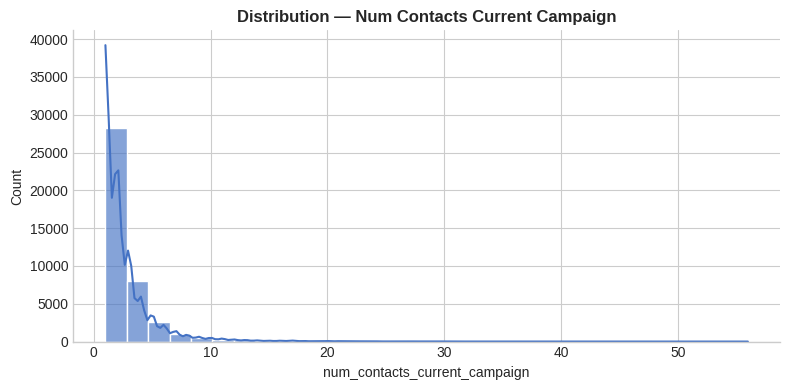

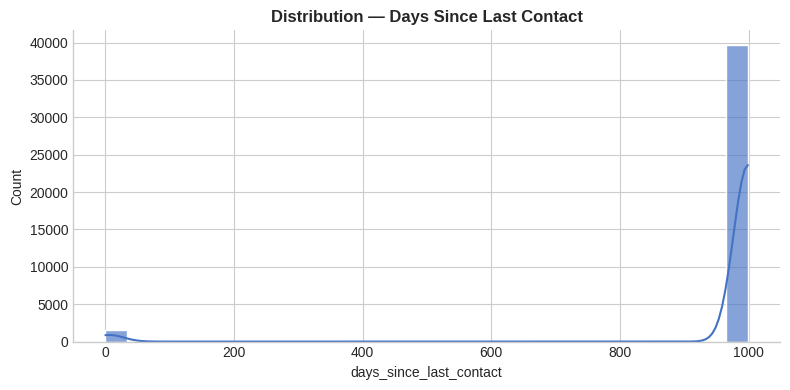

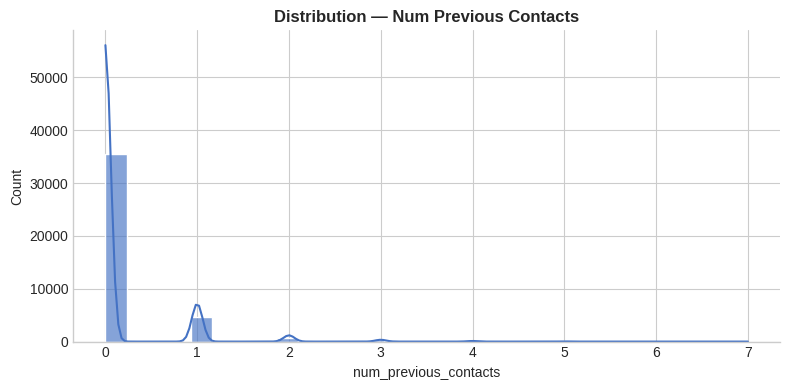

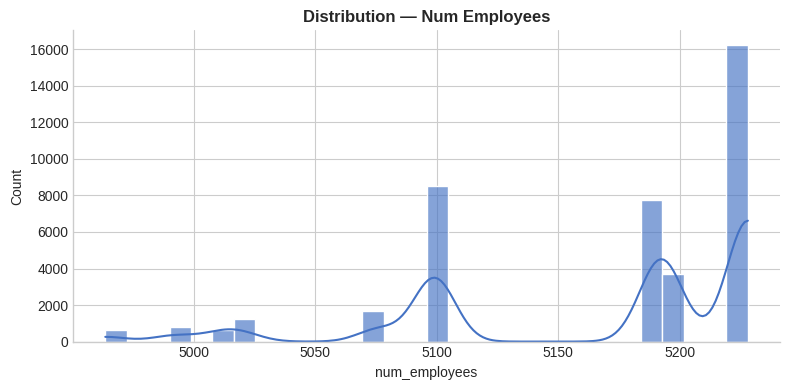

In [ ]:
# Exclude macro variables — plotted separately by month below
macro_cols = ['employment_variation_rate', 'consumer_price_index',
              'consumer_confidence_index', 'euribor_3_month_rate']
filtered_numerical_cols = [col for col in numerical_cols if col not in macro_cols]

for col in filtered_numerical_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 color='#4472C4', alpha=0.65, edgecolor='white', ax=ax)
    ax.set_title(f'Distribution — {col.replace("_"," ").title()}', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()

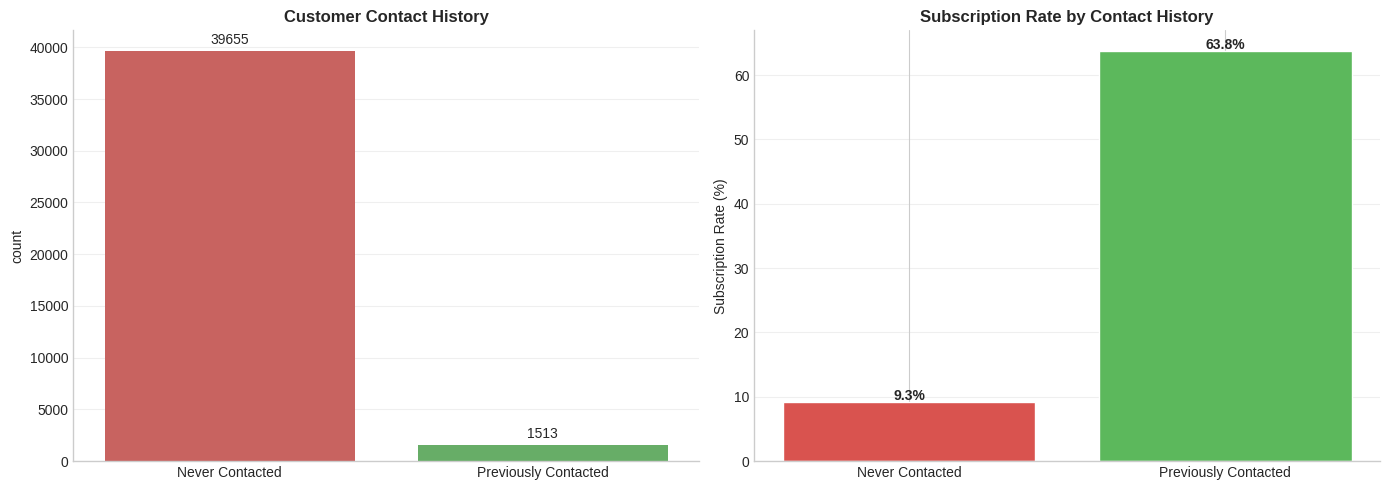

In [ ]:
# pdays=999 Days since last contact is a sentinel value meaning the customer was never previously contacted
df['contact_status'] = np.where(df['days_since_last_contact'] == 999,
                                 'Never Contacted', 'Previously Contacted')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='contact_status', ax=axes[0], palette=['#D9534F','#5CB85C'])
for c in axes[0].containers:
    axes[0].bar_label(c, fontsize=10, padding=3)
axes[0].set_title('Customer Contact History', fontweight='bold')
axes[0].set_xlabel(''); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

sub_rates = df.groupby('contact_status')['is_subscribed'].mean() * 100
axes[1].bar(sub_rates.index, sub_rates.values, color=['#D9534F','#5CB85C'], edgecolor='white')
for i, (idx, val) in enumerate(sub_rates.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Subscription Rate by Contact History', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)'); axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()
# Previously contacted customers convert at a higher rate, confirming H1 direction

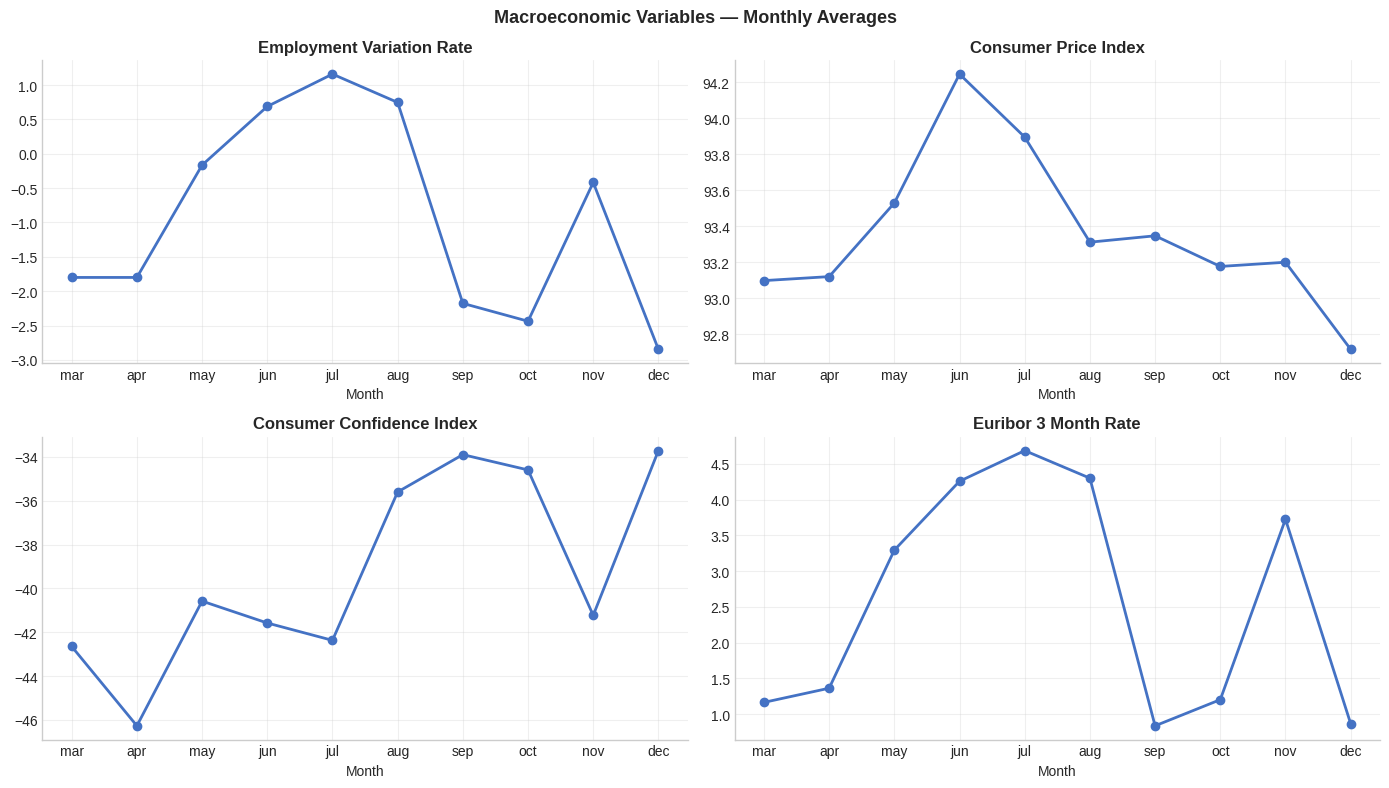

In [ ]:
# Monthly trend of macroeconomic variables to identify campaign timing patterns
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(macro_cols):
    monthly_avg = (df.groupby('last_contact_month')[col]
                     .mean()
                     .reindex(month_order))
    axes[i].plot(month_order, monthly_avg.values, marker='o', color='#4472C4', linewidth=2)
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_xlabel('Month'); axes[i].grid(alpha=0.3)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Macroeconomic Variables — Monthly Averages', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# Macro variables show clear seasonal structure; used to time optimal campaign windows

### 4.5 Bivariate Analysis — Categorical Variables vs Subscription Rate

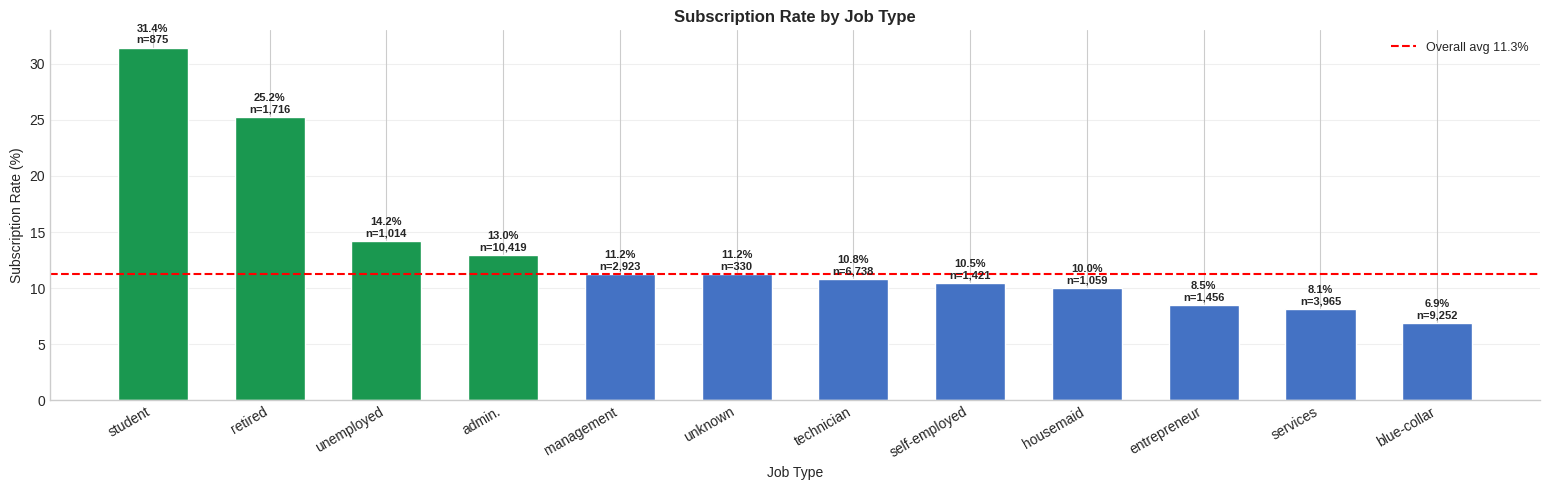

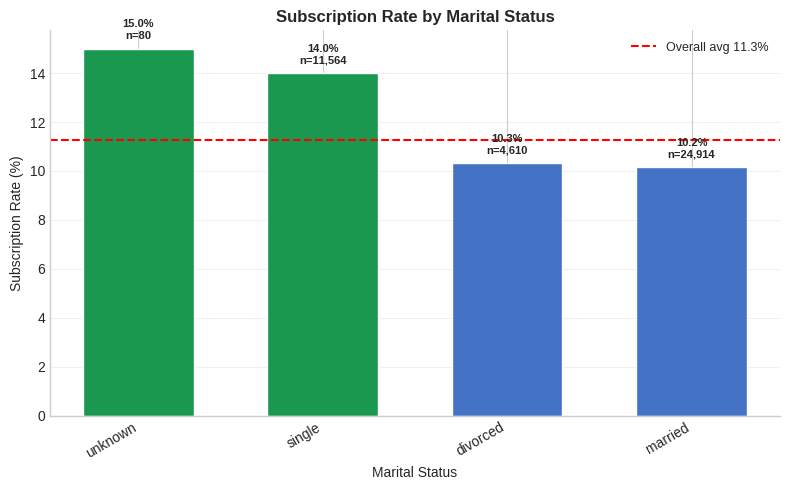

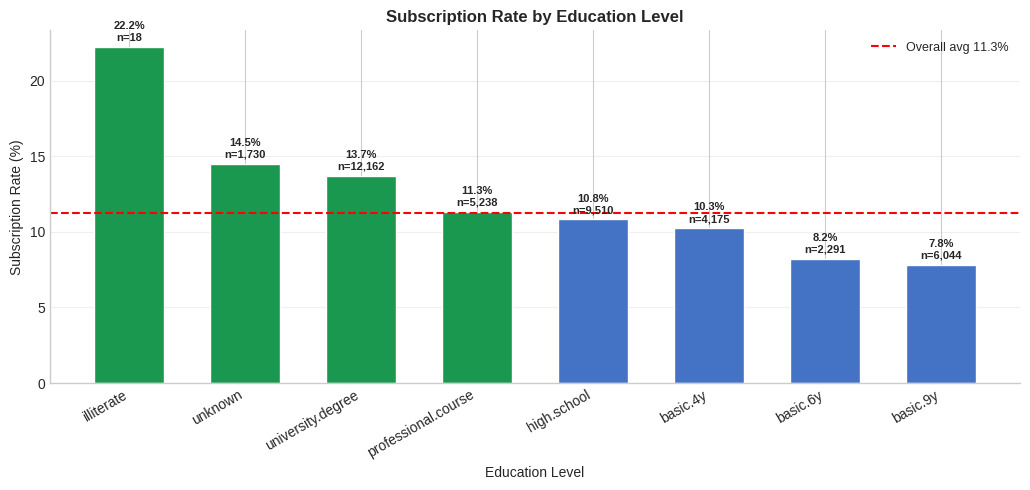

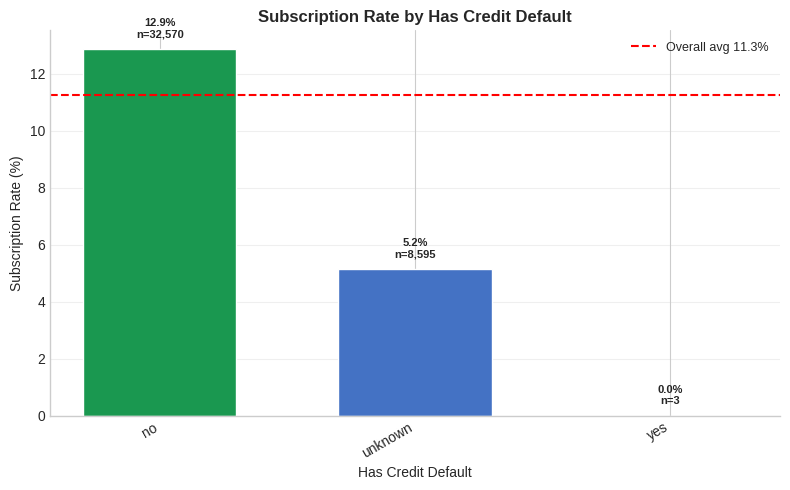

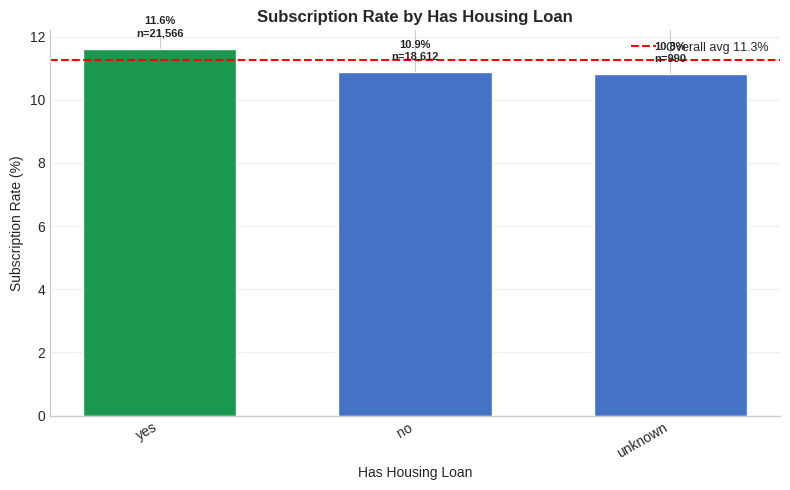

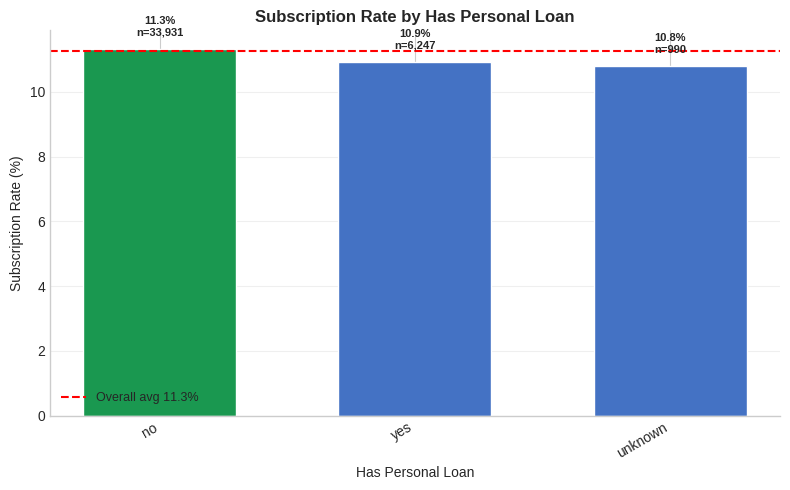

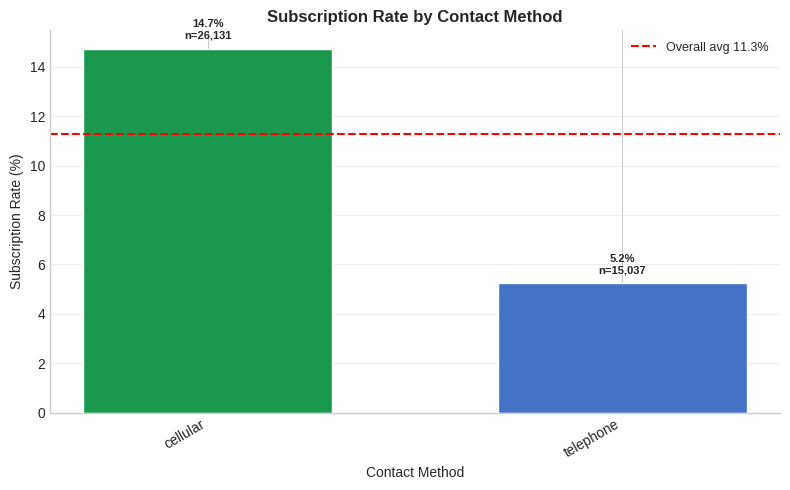

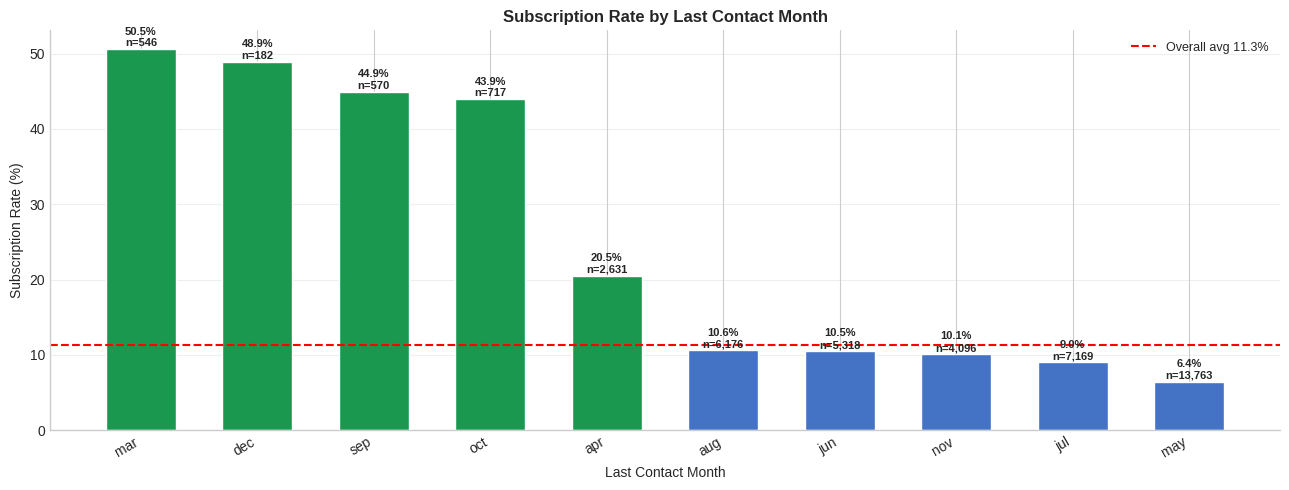

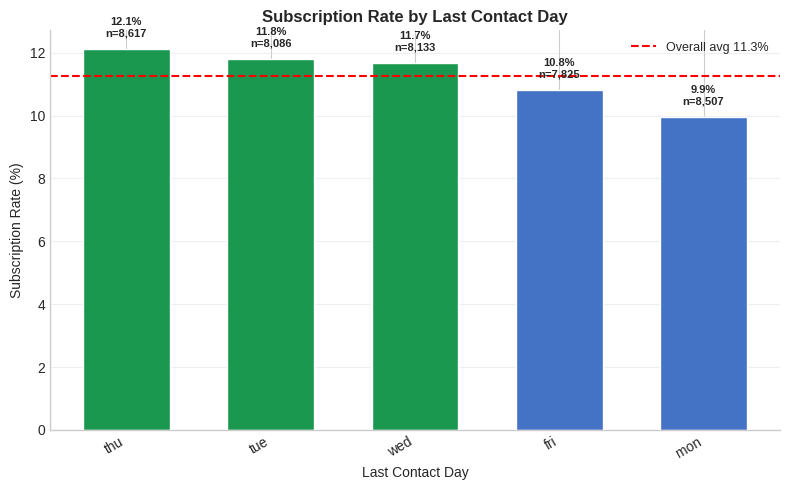

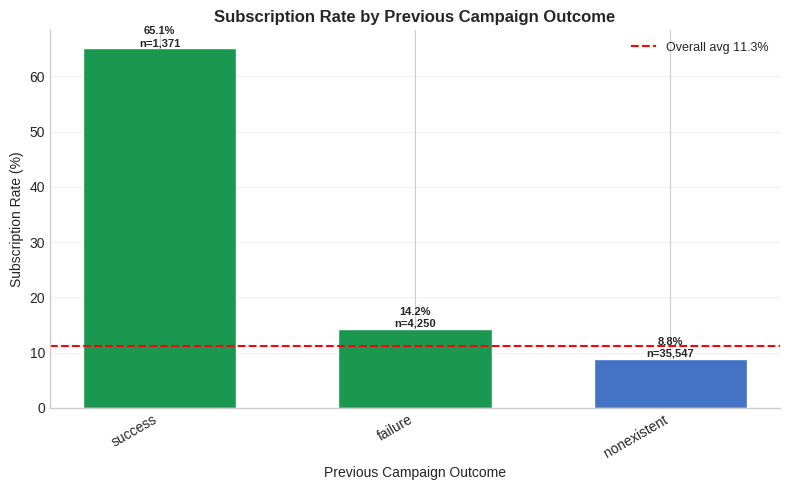

In [ ]:
# Subscription rate per category for every categorical column
# Green bar = above overall average; blue = below average
cat_bivar_cols = [
    'job_type', 'marital_status', 'education_level',
    'has_credit_default', 'has_housing_loan', 'has_personal_loan',
    'contact_method', 'last_contact_month', 'last_contact_day',
    'previous_campaign_outcome'
]

overall_rate = df['is_subscribed'].mean() * 100

for col in cat_bivar_cols:
    grp = (df.groupby(col)['is_subscribed']
             .agg(['mean', 'count'])
             .sort_values('mean', ascending=False)
             .reset_index())
    grp['rate'] = grp['mean'] * 100

    fig, ax = plt.subplots(figsize=(max(8, len(grp) * 1.3), 5))
    colors = ['#1a9850' if r > overall_rate else '#4472C4' for r in grp['rate']]
    bars = ax.bar(grp[col].astype(str), grp['rate'],
                  color=colors, edgecolor='white', width=0.6)

    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{row['rate']:.1f}%\nn={row['count']:,}",
                ha='center', fontsize=8, fontweight='bold')

    ax.axhline(overall_rate, color='red', linestyle='--',
               linewidth=1.5, label=f'Overall avg {overall_rate:.1f}%')
    ax.set_title(f'Subscription Rate by {col.replace("_", " ").title()}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Subscription Rate (%)')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()

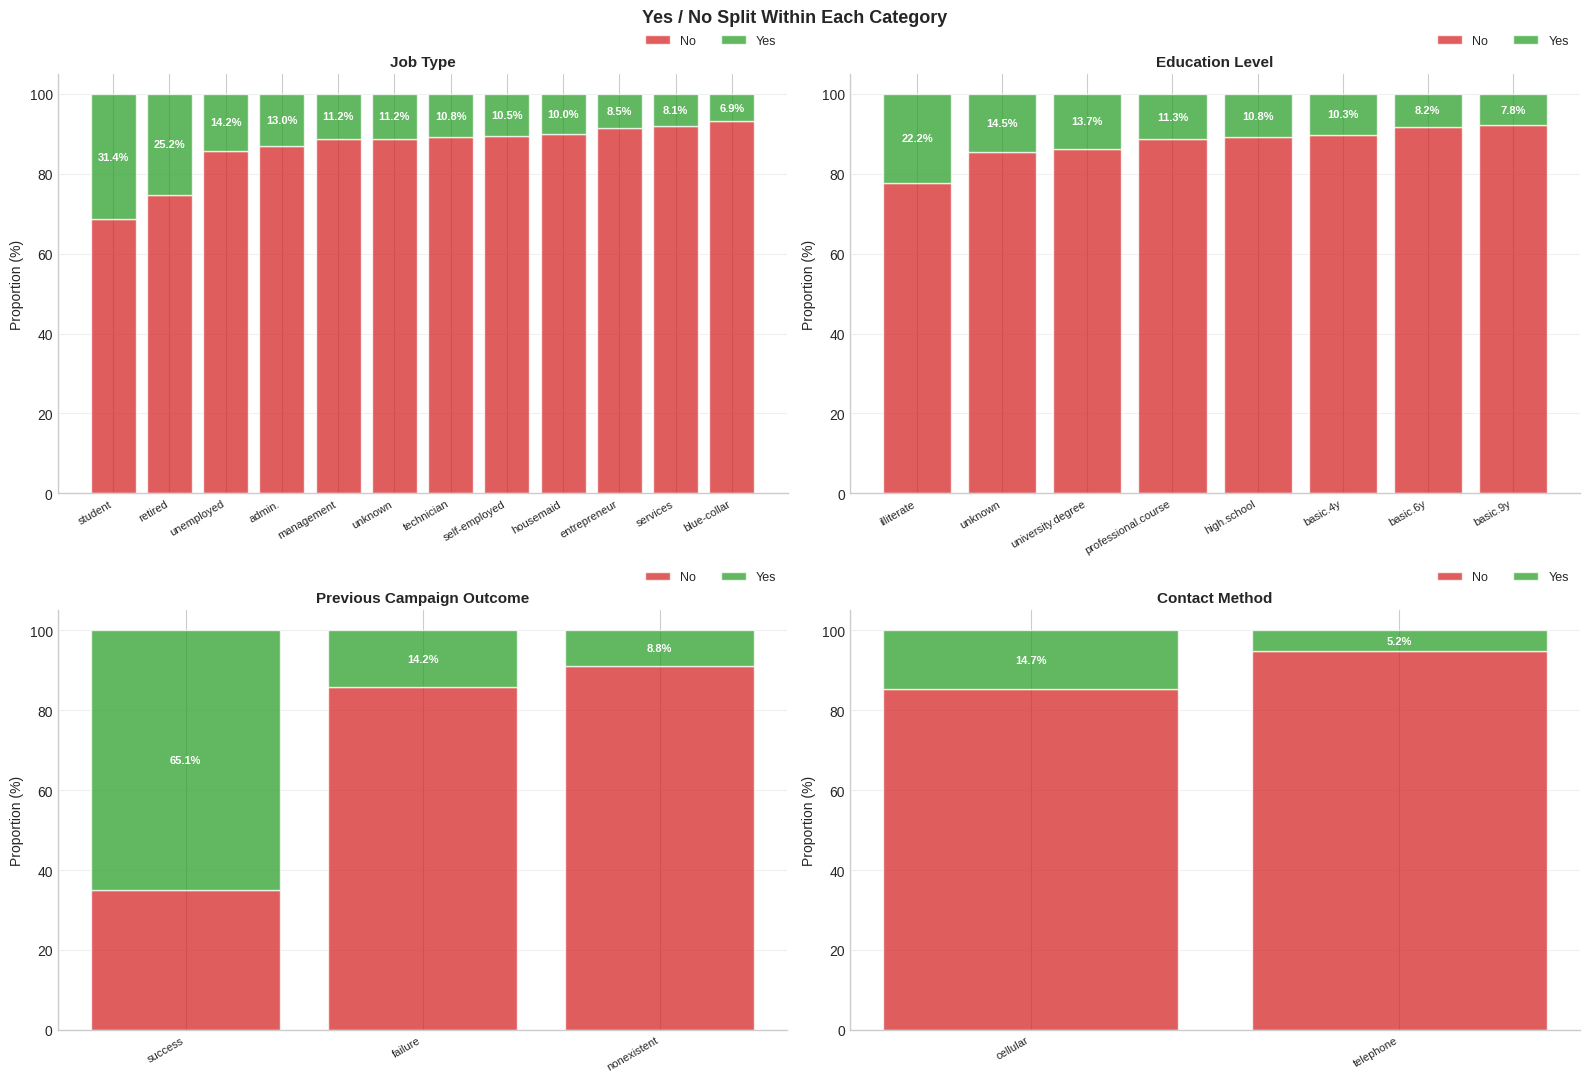

In [ ]:
# Stacked bar shows the Yes/No split within each category simultaneously
# Makes it easy to spot which categories have disproportionately high subscription
key_cats = [
    'job_type', 'education_level',
    'previous_campaign_outcome', 'contact_method'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, col in zip(axes, key_cats):
    ct = pd.crosstab(df[col], df['is_subscribed'], normalize='index') * 100
    ct.columns = ['No', 'Yes']
    ct = ct.sort_values('Yes', ascending=False)

    no_bars  = ax.bar(range(len(ct)), ct['No'],
                      color='#D62728', alpha=0.75, label='No', edgecolor='white')
    yes_bars = ax.bar(range(len(ct)), ct['Yes'],
                      bottom=ct['No'], color='#2CA02C',
                      alpha=0.75, label='Yes', edgecolor='white')

    # Label the Yes % inside the green segment
    for i, (idx, row) in enumerate(ct.iterrows()):
        ax.text(i, row['No'] + row['Yes'] / 2,
                f"{row['Yes']:.1f}%",
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels(ct.index.astype(str), rotation=30, ha='right', fontsize=8)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    ax.set_ylabel('Proportion (%)')
    ax.legend(loc='upper right', bbox_to_anchor=(1, 1.12),
          ncol=2, fontsize=9, frameon=False)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Yes / No Split Within Each Category',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

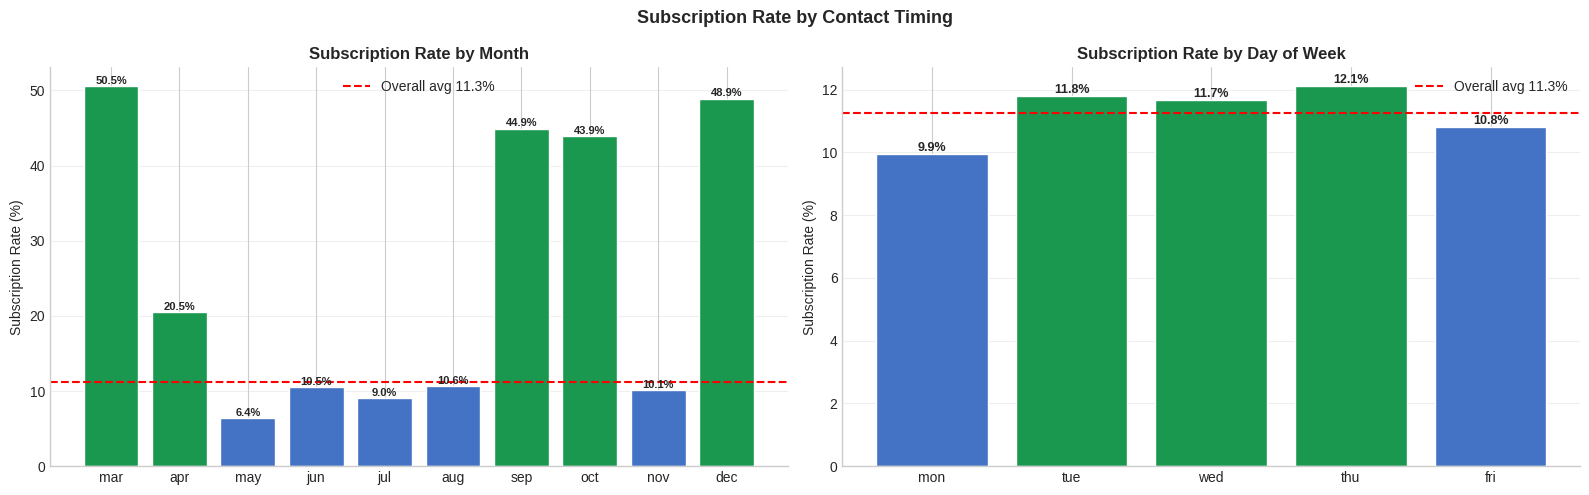

In [ ]:
# Subscription rate by contact month and day of week
# Reveals which contact windows produce the highest conversion
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order   = ['mon','tue','wed','thu','fri']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Month
month_rates = (df.groupby('last_contact_month')['is_subscribed']
                 .mean()
                 .reindex(month_order) * 100)
colors_m = ['#1a9850' if r > overall_rate else '#4472C4'
            for r in month_rates]
bars = axes[0].bar(month_order, month_rates,
                   color=colors_m, edgecolor='white')
for bar, val in zip(bars, month_rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[0].axhline(overall_rate, color='red', linestyle='--',
                linewidth=1.5, label=f'Overall avg {overall_rate:.1f}%')
axes[0].set_title('Subscription Rate by Month', fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Day of week
day_rates = (df.groupby('last_contact_day')['is_subscribed']
               .mean()
               .reindex(day_order) * 100)
colors_d = ['#1a9850' if r > overall_rate else '#4472C4'
            for r in day_rates]
bars = axes[1].bar(day_order, day_rates,
                   color=colors_d, edgecolor='white')
for bar, val in zip(bars, day_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(overall_rate, color='red', linestyle='--',
                linewidth=1.5, label=f'Overall avg {overall_rate:.1f}%')
axes[1].set_title('Subscription Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Subscription Rate by Contact Timing',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.6 Bivariate Analysis — Numerical Variables vs Subscription Rate

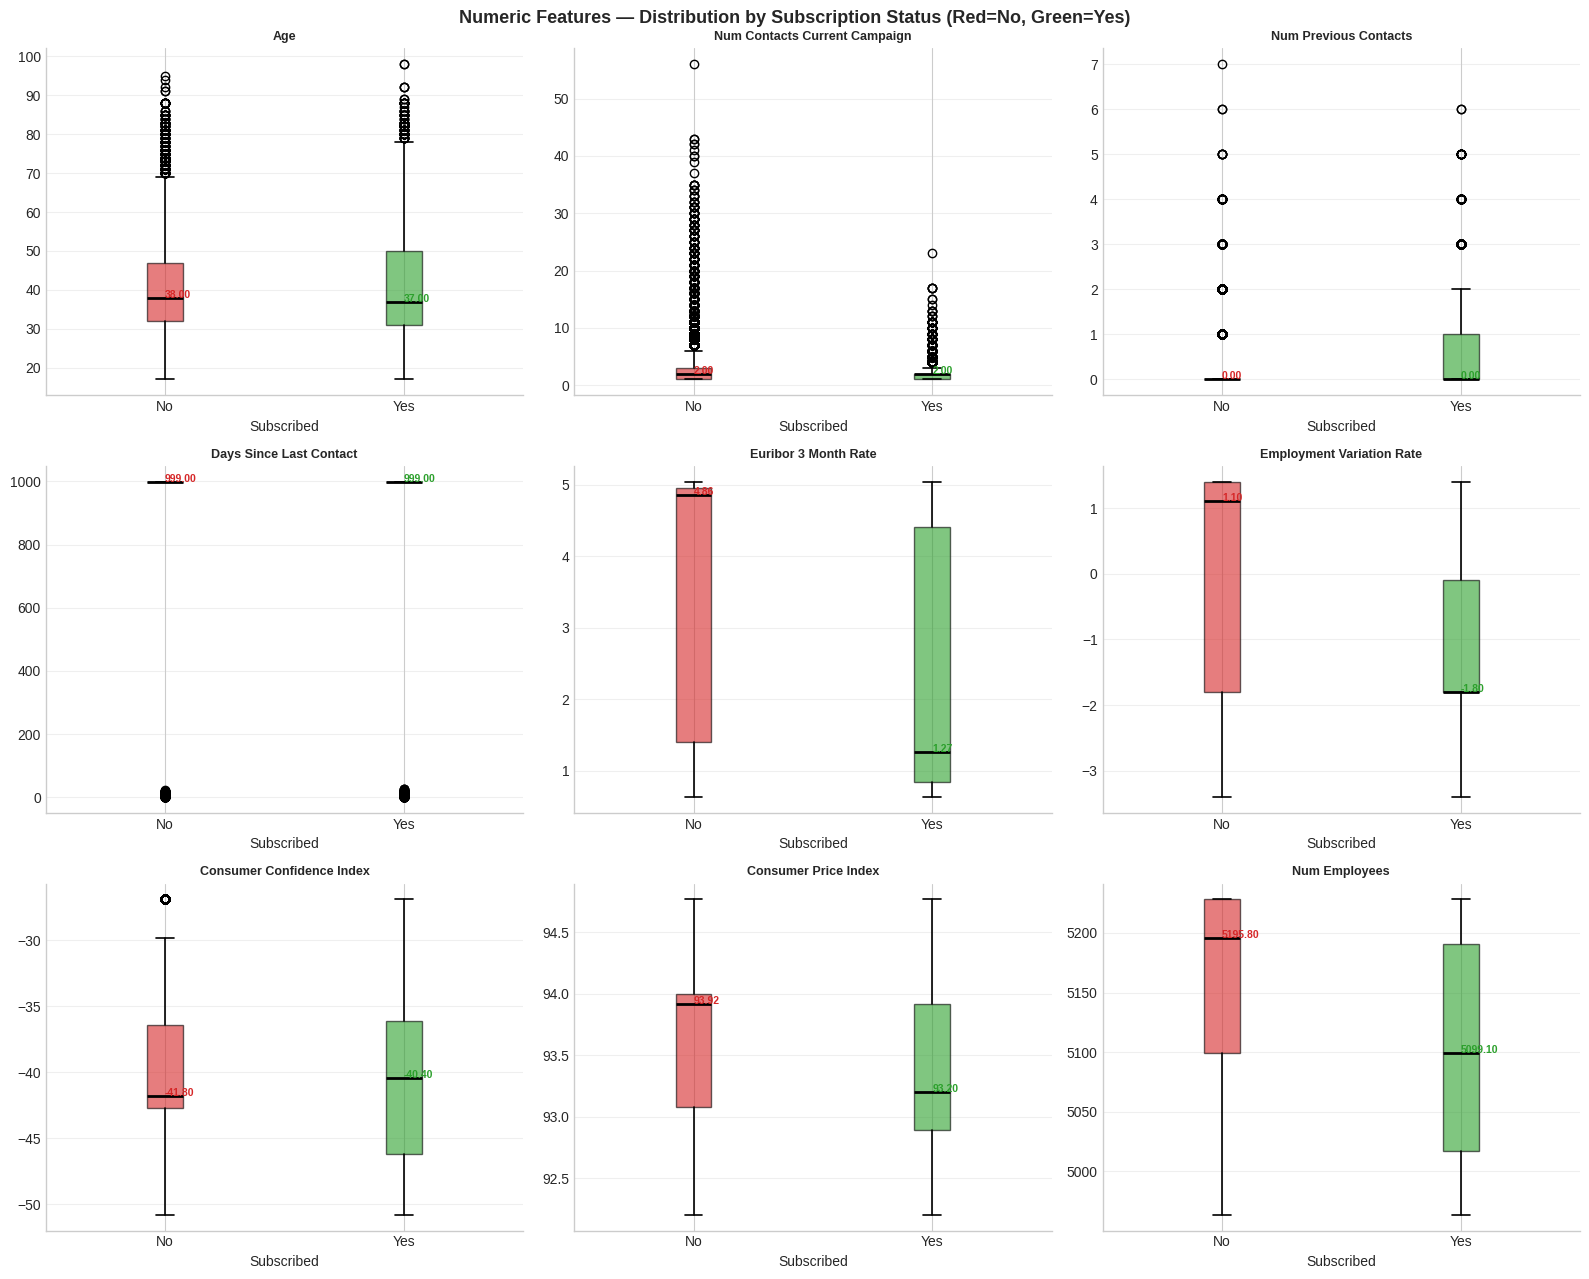

In [ ]:
# Box plots show whether the numeric distributions differ between subscribers and non-subscribers
# A large gap between red and green medians = strong predictor
num_bivar_cols = [
    'age', 'num_contacts_current_campaign', 'num_previous_contacts',
    'days_since_last_contact', 'euribor_3_month_rate',
    'employment_variation_rate', 'consumer_confidence_index',
    'consumer_price_index', 'num_employees'
]

n = len(num_bivar_cols)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for ax, col in zip(axes, num_bivar_cols):
    data_no  = df.loc[df['is_subscribed'] == 0, col].dropna()
    data_yes = df.loc[df['is_subscribed'] == 1, col].dropna()

    bp = ax.boxplot(
        [data_no, data_yes],
        patch_artist=True,
        labels=['No', 'Yes'],
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )
    bp['boxes'][0].set_facecolor('#D62728'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2CA02C'); bp['boxes'][1].set_alpha(0.6)

    # Annotate medians
    med_no  = data_no.median()
    med_yes = data_yes.median()
    ax.text(1, med_no,  f'{med_no:.2f}',  ha='left', fontsize=7.5, color='#D62728', fontweight='bold')
    ax.text(2, med_yes, f'{med_yes:.2f}', ha='left', fontsize=7.5, color='#2CA02C', fontweight='bold')

    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Subscribed')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Numeric Features — Distribution by Subscription Status (Red=No, Green=Yes)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

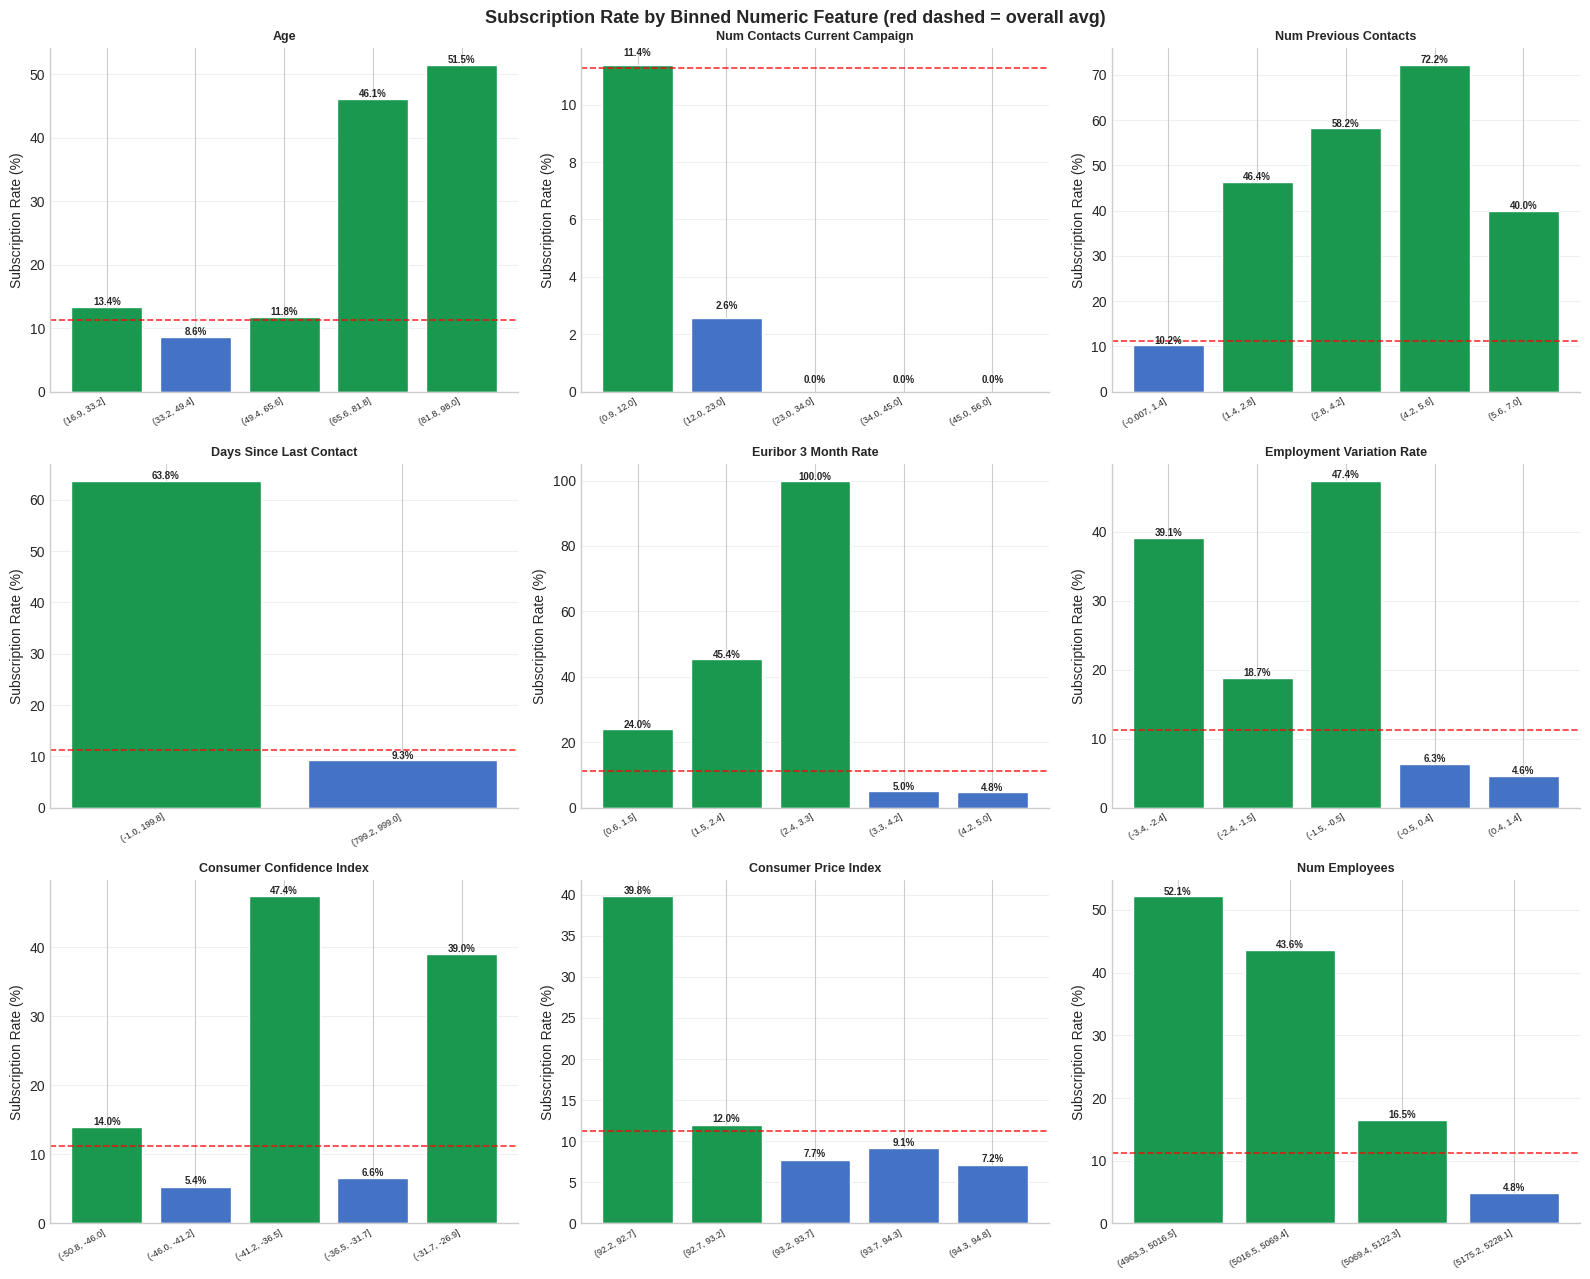

In [ ]:
# Bins each numeric variable into 5 equal ranges and plots the subscription rate per bin
# Shows whether the relationship with subscription is linear, curved, or threshold-based
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for ax, col in zip(axes, num_bivar_cols):
    temp = df[[col, 'is_subscribed']].dropna().copy()
    temp['bin'] = pd.cut(temp[col], bins=5, precision=1)
    binned = (temp.groupby('bin', observed=True)['is_subscribed']
                  .agg(['mean', 'count'])
                  .reset_index())
    binned['rate'] = binned['mean'] * 100

    colors_b = ['#1a9850' if r > overall_rate else '#4472C4'
                for r in binned['rate']]
    ax.bar(range(len(binned)), binned['rate'],
           color=colors_b, edgecolor='white')

    for i, (_, row) in enumerate(binned.iterrows()):
        ax.text(i, row['rate'] + 0.3,
                f"{row['rate']:.1f}%",
                ha='center', fontsize=7, fontweight='bold')

    ax.axhline(overall_rate, color='red', linestyle='--',
               linewidth=1.2, alpha=0.8)
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(binned['bin'].astype(str),
                       rotation=30, ha='right', fontsize=6.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.set_ylabel('Subscription Rate (%)')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Subscription Rate by Binned Numeric Feature (red dashed = overall avg)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Statistical Analysis
### 5.1 Correlation Matrix

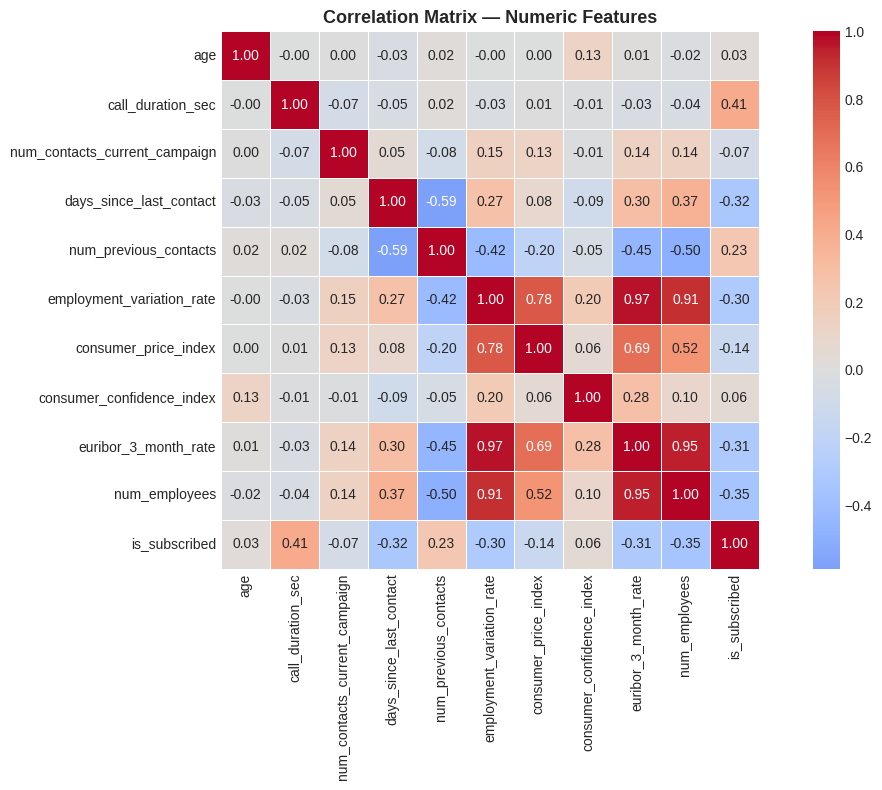

In [ ]:
numeric_with_target = numerical_cols + ['is_subscribed']
corr = df[numeric_with_target].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# euribor_3_month_rate is strongly correlated with num_employees — multicollinearity confirmed by VIF below

### 5.2 Chi-Square Tests — Categorical Features vs Subscription

In [ ]:
cat_test_cols = ['job_type', 'marital_status', 'education_level', 'has_credit_default',
                 'has_housing_loan', 'has_personal_loan', 'contact_method',
                 'previous_campaign_outcome']

print('CHI-SQUARE TESTS — Categorical Features vs Subscription')
print('=' * 65)
print(f"  {'Feature':<35} {'chi2':>8}  {'p-value':>10}  {'dof':>4}  Sig?")
print('-' * 65)
for col in cat_test_cols:
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[col], df['is_subscribed']))
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'  {col:<35} {chi2:>8.2f}  {p:>10.4f}  {dof:>4}  {sig}')
# All features with p < 0.05 have a statistically significant association with the target

CHI-SQUARE TESTS — Categorical Features vs Subscription
  Feature                                 chi2     p-value   dof  Sig?
-----------------------------------------------------------------
  job_type                              960.02      0.0000    11  Yes
  marital_status                        123.24      0.0000     3  Yes
  education_level                       192.40      0.0000     7  Yes
  has_credit_default                    406.17      0.0000     2  Yes
  has_housing_loan                        5.76      0.0560     2  No
  has_personal_loan                       1.07      0.5845     2  No
  contact_method                        860.83      0.0000     1  Yes
  previous_campaign_outcome            4217.66      0.0000     2  Yes


### 5.3 Point-Biserial Correlations — Numeric Features vs Subscription

In [ ]:
numeric_test_cols = [c for c in numerical_cols if c != 'call_duration_sec']

print('POINT-BISERIAL CORRELATIONS — Numeric Features vs Subscription')
print('=' * 65)
print(f"  {'Feature':<35} {'r':>7}  {'p-value':>10}  Is_Significant")
print('-' * 65)
for col in numeric_test_cols:
    r, p = pointbiserialr(df['is_subscribed'], df[col].fillna(df[col].median()))
    print(f"  {col:<35} {r:>7.4f}  {p:>10.4f}  {'Yes' if p < 0.05 else 'No'}")
# euribor_3_month_rate has the strongest negative correlation — lower rates drive more subscriptions

POINT-BISERIAL CORRELATIONS — Numeric Features vs Subscription
  Feature                                   r     p-value  Is_Significant
-----------------------------------------------------------------
  age                                  0.0303      0.0000  Yes
  num_contacts_current_campaign       -0.0663      0.0000  Yes
  days_since_last_contact             -0.3245      0.0000  Yes
  num_previous_contacts                0.2300      0.0000  Yes
  employment_variation_rate           -0.2983      0.0000  Yes
  consumer_price_index                -0.1364      0.0000  Yes
  consumer_confidence_index            0.0551      0.0000  Yes
  euribor_3_month_rate                -0.3076      0.0000  Yes
  num_employees                       -0.3545      0.0000  Yes


### 5.4 Variance Inflation Factor (VIF)

In [ ]:
vif_cols = [c for c in numerical_cols if c != 'call_duration_sec']
X_vif = add_constant(df[vif_cols].dropna())

vif_df = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print(f"  {'Feature':<35} {'VIF':>8}  Flag")
print('-' * 55)
for _, row in vif_df.iterrows():
    flag = 'High' if row['VIF'] > 10 else ''
    print(f"  {row['Feature']:<35} {row['VIF']:>8.2f}  {flag}")
# VIF > 10 confirms multicollinearity among macro variables — Ridge regularisation in Model 2 addresses this

  Feature                                  VIF  Flag
-------------------------------------------------------
  euribor_3_month_rate                   64.38  High
  employment_variation_rate              33.06  High
  num_employees                          31.69  High
  consumer_price_index                    6.33  
  consumer_confidence_index               2.65  
  num_previous_contacts                   1.80  
  days_since_last_contact                 1.61  
  num_contacts_current_campaign           1.03  
  age                                     1.02  


## 6. Data Preparation
### 6.1 Feature Engineering

In [ ]:
# Convert the pdays=999 sentinel to an interpretable binary flag
df['previously_contacted'] = (df['days_since_last_contact'] != 999).astype(int)

# call_duration is only known after the call ends — keeping it would leak the target
df = df.drop(columns=['call_duration_sec'], errors='ignore')

print(f'Previously contacted : {df["previously_contacted"].sum():,}')
print(f'Never contacted      : {(df["previously_contacted"]==0).sum():,}')
print(f'Shape after leakage drop: {df.shape}')

Previously contacted : 1,513
Never contacted      : 39,655
Shape after leakage drop: (41168, 23)


### 6.2 Label Encoding Categorical Columns

In [ ]:
cat_cols = ['job_type', 'marital_status', 'education_level', 'has_credit_default',
            'has_housing_loan', 'has_personal_loan', 'contact_method',
            'last_contact_month', 'last_contact_day', 'previous_campaign_outcome']

le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
# LabelEncoder converts string categories to integers; suitable for tree-based models
print('Encoded columns created.')

Encoded columns created.


### 6.3 Feature Selection — Extra Trees Importance

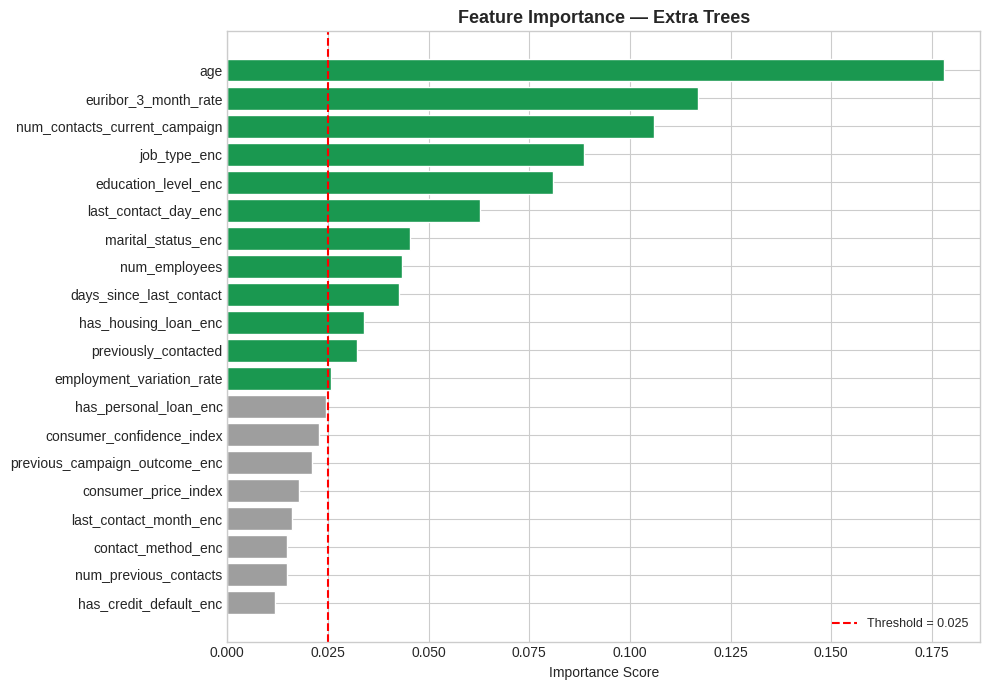

Selected (12 features, importance >= 0.025):
                      Feature  Importance
                          age    0.178056
         euribor_3_month_rate    0.116919
num_contacts_current_campaign    0.105940
                 job_type_enc    0.088613
          education_level_enc    0.080886
         last_contact_day_enc    0.062780
           marital_status_enc    0.045363
                num_employees    0.043300
      days_since_last_contact    0.042603
         has_housing_loan_enc    0.034059
         previously_contacted    0.032209
    employment_variation_rate    0.025643

Dropped  (8 features, importance < 0.025):
                      Feature  Importance
        has_personal_loan_enc    0.024526
    consumer_confidence_index    0.022758
previous_campaign_outcome_enc    0.021122
         consumer_price_index    0.017695
       last_contact_month_enc    0.015961
           contact_method_enc    0.014929
        num_previous_contacts    0.014780
       has_credit_default_enc

In [ ]:
THRESHOLD = 0.025

feat_imp = pd.DataFrame({'Feature': X_all.columns, 'Importance': et.feature_importances_})\
             .sort_values('Importance', ascending=False)

# Green = above threshold (selected), grey = below threshold (dropped)
colors = ['#1a9850' if v >= THRESHOLD else '#9E9E9E'
          for v in feat_imp['Importance'][::-1]]

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
         color=colors, edgecolor='white')
plt.axvline(THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, label=f'Threshold = {THRESHOLD}')
plt.title('Feature Importance — Extra Trees', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Summary of selected vs dropped features
selected = feat_imp[feat_imp['Importance'] >= THRESHOLD]
dropped  = feat_imp[feat_imp['Importance'] <  THRESHOLD]
print(f"Selected ({len(selected)} features, importance >= {THRESHOLD}):")
print(selected.to_string(index=False))
print(f"\nDropped  ({len(dropped)} features, importance < {THRESHOLD}):")
print(dropped.to_string(index=False))

### 6.4 Train/Test Split & Scaling

In [ ]:
FEATURES = ['age', 'euribor_3_month_rate', 'num_contacts_current_campaign',
            'job_type_enc', 'education_level_enc', 'last_contact_day_enc',
            'marital_status_enc', 'num_employees', 'days_since_last_contact',
            'has_housing_loan_enc']

model_df = df[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES]
y = model_df[TARGET]

# Stratify preserves the ~11% subscription rate in both train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaler fitted only on train set to prevent data leakage into the test set
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}  Test: {y_test.mean():.2%}')

Train: (32934, 10)  Test: (8234, 10)
Train positive rate: 11.26%  Test: 11.26%


## 7. Model Building
### 7.1 SMOTEENN — Balancing Training Data

In [ ]:
# Unscaled balanced set for tree-based models
smoteenn_raw = SMOTEENN(random_state=42)
X_train_sm, y_train_sm = smoteenn_raw.fit_resample(X_train, y_train)
X_train_sm = pd.DataFrame(X_train_sm, columns=FEATURES)

neg, pos = np.bincount(y_train_sm)
print(f'Unscaled SMOTEENN -> No: {neg:,}  Yes: {pos:,}')

# Scaled balanced set for parametric models
smoteenn_sc = SMOTEENN(random_state=42)
X_train_sm_sc, y_train_sm_sc = smoteenn_sc.fit_resample(X_train_sc, y_train)

neg_sc, pos_sc = np.bincount(y_train_sm_sc)
print(f'Scaled  SMOTEENN -> No: {neg_sc:,}  Yes: {pos_sc:,}')
# SMOTEENN combines SMOTE oversampling and ENN undersampling to clean class boundaries

Unscaled SMOTEENN -> No: 19,163  Yes: 25,687
Scaled  SMOTEENN -> No: 20,318  Yes: 24,494


### 7.2 Model Definitions

| # | Model | Type | Justification |
|---|-------|------|---------------|
| 1 | Logistic Regression | Parametric | MLE-based; interpretable coefficients and odds ratios |
| 2 | Ridge LR | Parametric | L2 regularisation mitigates multicollinearity confirmed by VIF |
| 3 | Decision Tree | Non-Parametric | Human-readable rules; no distributional assumptions |
| 4 | Random Forest | Non-Parametric | Ensemble reduces variance of single tree |
| 5 | Gaussian Naive Bayes | Parametric | Bayesian baseline; explicit class priors and likelihoods |
| 6 | K-Nearest Neighbors | Non-Parametric | Instance-based; no model training required |
| 7 | LightGBM | Non-Parametric | Gradient-boosted trees; state-of-the-art on tabular data |

In [ ]:
from lightgbm import LGBMClassifier

MODELS = [
    {
        'name'     : 'Model 1 - Logistic Regression',
        'type'     : 'Parametric',
        'scaled'   : True,
        'threshold': 0.55,
        'model'    : LogisticRegression(max_iter=2000, C=0.5, penalty='l2',
                                         solver='lbfgs', random_state=42)
    },
    {
        'name'     : 'Model 2 - Ridge LR',
        'type'     : 'Parametric',
        'scaled'   : True,
        'threshold': 0.50,
        # CalibratedClassifierCV adds predict_proba to RidgeClassifier via Platt scaling
        'model'    : CalibratedClassifierCV(RidgeClassifier(alpha=2.0), cv=3, method='sigmoid')
    },
    {
        'name'     : 'Model 3 - Decision Tree',
        'type'     : 'Non-Parametric',
        'scaled'   : False,
        'threshold': 0.50,
        'model'    : DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
    },
    {
        'name'     : 'Model 4 - Random Forest',
        'type'     : 'Non-Parametric',
        'scaled'   : False,
        'threshold': 0.50,
        'model'    : RandomForestClassifier(n_estimators=200, max_depth=10,
                                             random_state=42, n_jobs=-1)
    },
    {
        'name'     : 'Model 5 - Gaussian Naive Bayes',
        'type'     : 'Parametric',
        'scaled'   : True,
        'threshold': 0.50,
        'model'    : GaussianNB()
    },
    {
        'name'     : 'Model 6 - K-Nearest Neighbors',
        'type'     : 'Non-Parametric',
        'scaled'   : True,
        'threshold': 0.50,
        'model'    : KNeighborsClassifier(n_neighbors=15, metric='euclidean', n_jobs=-1)
    },
    {
        'name'     : 'Model 7 - LightGBM',
        'type'     : 'Non-Parametric',
        'scaled'   : False,
        'threshold': 0.50,
        'model'    : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                     num_leaves=40, random_state=42, n_jobs=-1, verbose=-1)
    },
]

### 7.3 Training Loop

In [ ]:
fitted  = {}
results = []

for m in MODELS:
    name = m['name']
    # Parametric models use scaled SMOTEENN data; tree models use unscaled
    X_tr = X_train_sm_sc if m['scaled'] else X_train_sm.values
    y_tr = y_train_sm_sc  if m['scaled'] else y_train_sm
    X_te = X_test_sc      if m['scaled'] else X_test.values

    clf = m['model']
    clf.fit(X_tr, y_tr)
    fitted[name] = clf

    prob = clf.predict_proba(X_te)[:, 1]
    pred = (prob >= m['threshold']).astype(int)

    results.append({
        'Model'    : name,
        'Type'     : m['type'],
        'Accuracy' : accuracy_score(y_test,  pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall'   : recall_score(y_test,    pred),
        'F1'       : f1_score(y_test,        pred),
        'ROC-AUC'  : roc_auc_score(y_test,   prob)
    })


results_df = pd.DataFrame(results)
display(results_df.set_index('Model').round(4))

,Type,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Model 1 - Logistic Regression,Parametric,0.7345,0.2589,0.7292,0.3821,0.7761
Model 2 - Ridge LR,Parametric,0.7272,0.2536,0.7325,0.3768,0.7752
Model 3 - Decision Tree,Non-Parametric,0.7723,0.2840,0.6721,0.3992,0.7851
Model 4 - Random Forest,Non-Parametric,0.8082,0.3293,0.6785,0.4434,0.7943
Model 5 - Gaussian Naive Bayes,Parametric,0.7512,0.2718,0.7206,0.3947,0.7799
Model 6 - K-Nearest Neighbors,Non-Parametric,0.6762,0.2148,0.7066,0.3295,0.7459
Model 7 - LightGBM,Non-Parametric,0.8522,0.4012,0.6354,0.4919,0.7946


## 8. Model Evaluation
### 8.1 Comparative Performance Chart

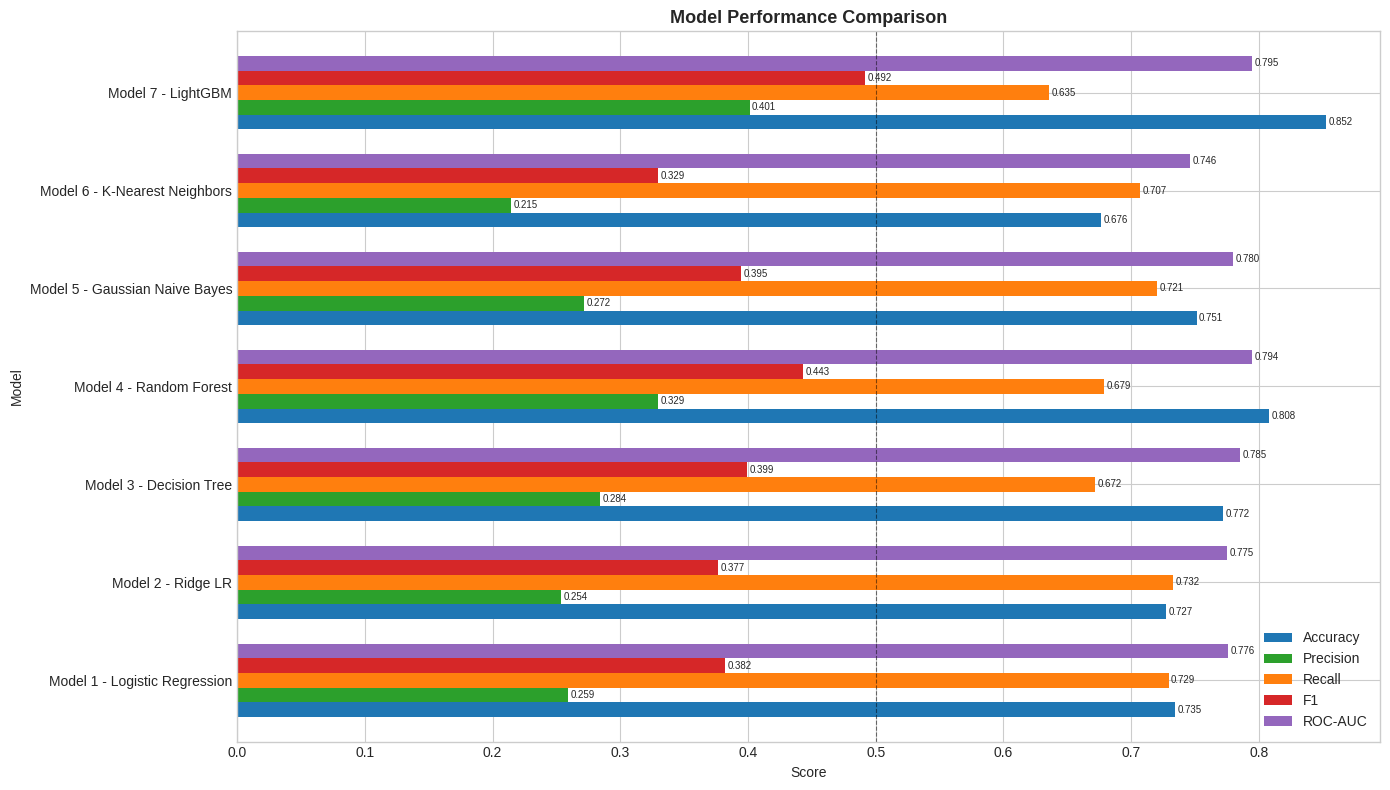

In [ ]:
metrics  = ['Accuracy','Precision','Recall','F1','ROC-AUC']
plot_df  = results_df.set_index('Model')[metrics]
colors   = ['#1F77B4','#2CA02C','#FF7F0E','#D62728','#9467BD']

ax = plot_df.plot(kind='barh', figsize=(14, 8), color=colors, width=0.75)
ax.set_xlabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='lower right')
for bar in ax.patches:
    w = bar.get_width()
    if w > 0.05:
        ax.text(w + 0.002, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=7)
plt.tight_layout(); plt.show()

### 8.2 ROC Curves

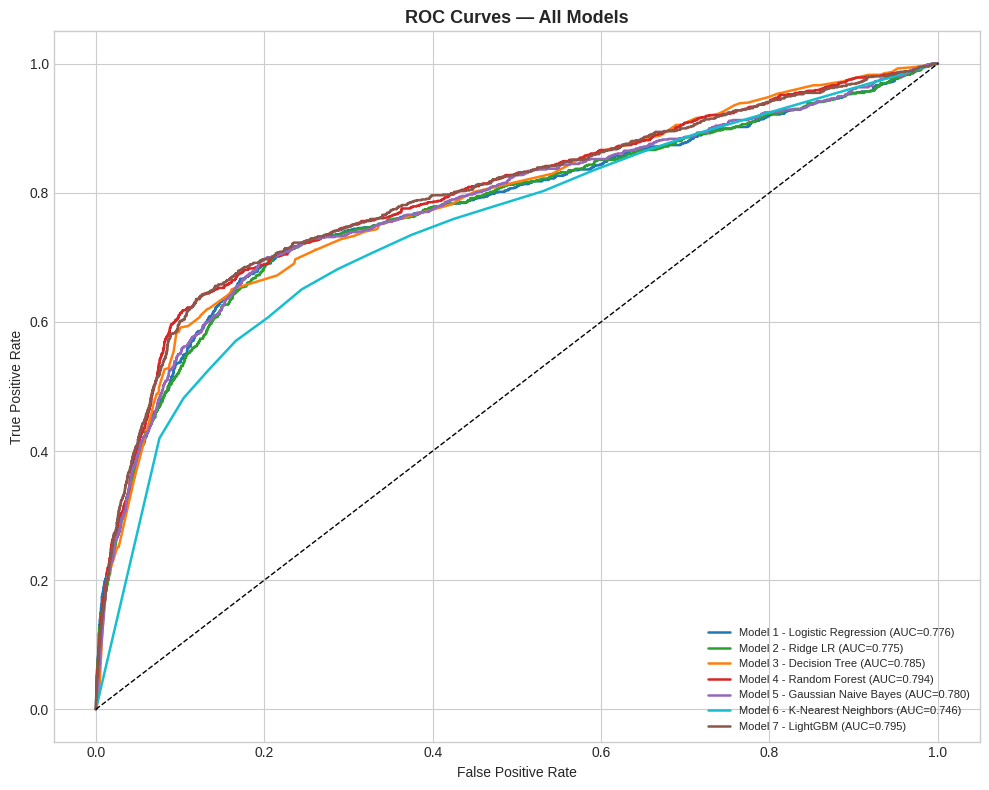

In [ ]:
colors_plot = ['#1F77B4','#2CA02C','#FF7F0E','#D62728','#9467BD','#17BECF','#8C564B']

plt.figure(figsize=(10, 8))
for m, color in zip(MODELS, colors_plot):
    name = m['name']
    X_te = X_test_sc if m['scaled'] else X_test.values
    prob = fitted[name].predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=1.8, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()
# Higher AUC indicates better discrimination between subscribers and non-subscribers

### 8.3 Confusion Matrices

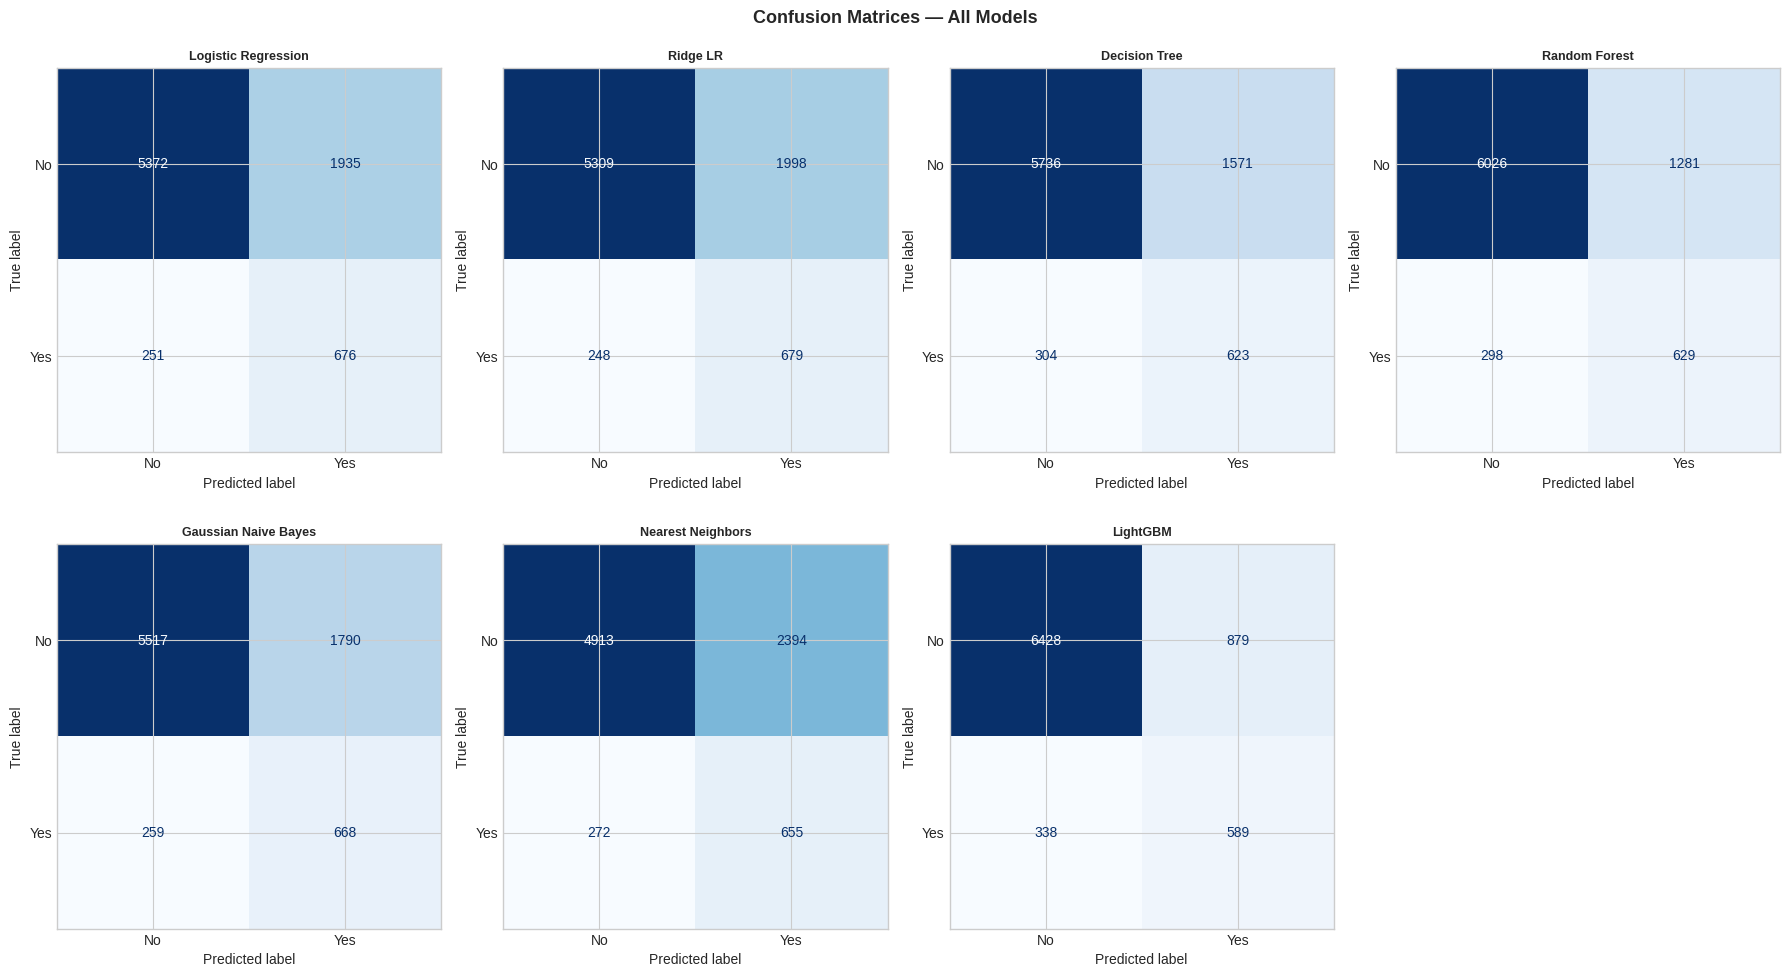

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, m in zip(axes, MODELS):
    name = m['name']
    X_te = X_test_sc if m['scaled'] else X_test.values
    prob = fitted[name].predict_proba(X_te)[:, 1]
    pred = (prob >= m['threshold']).astype(int)
    cm   = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name.split('-')[-1].strip(), fontsize=9, fontweight='bold')

for ax in axes[len(MODELS):]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# False negatives (missed subscribers) carry high opportunity cost — prioritise Recall

### 8.4 Predicted Probability Distributions

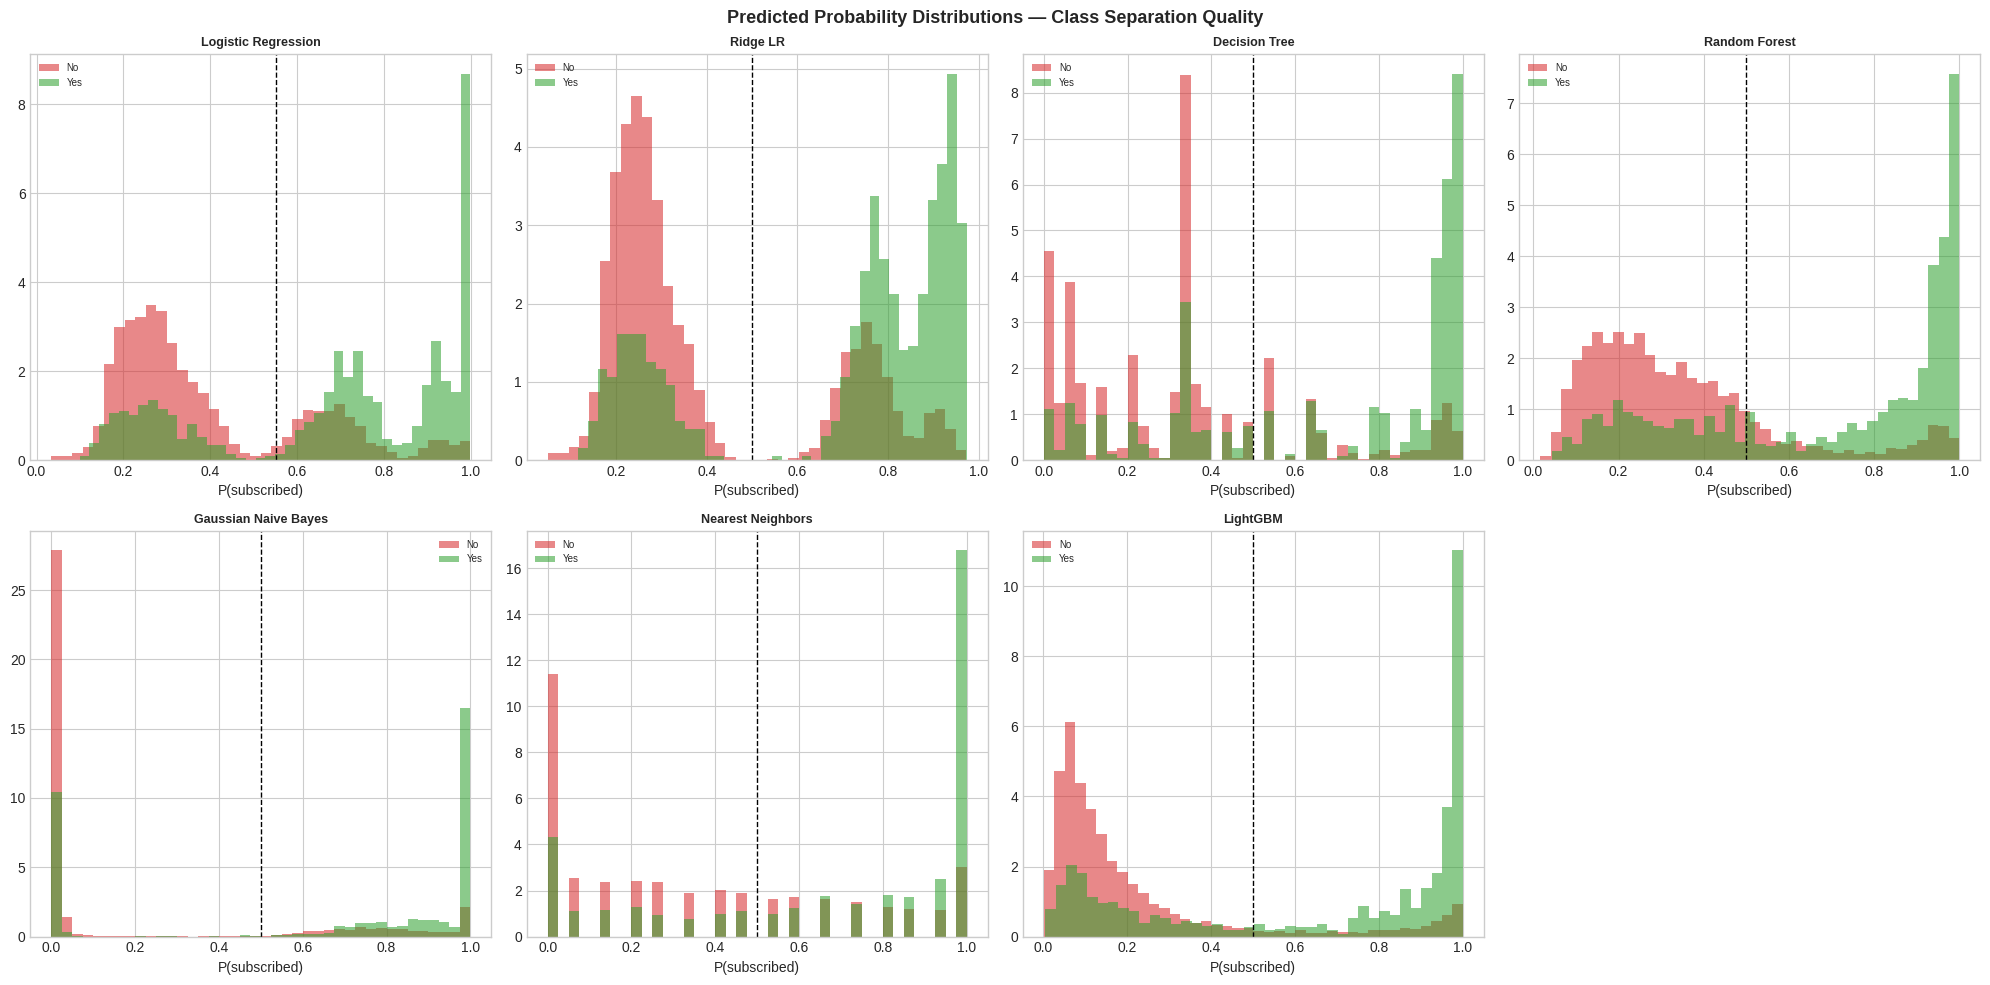

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, m in zip(axes, MODELS):
    name = m['name']
    X_te = X_test_sc if m['scaled'] else X_test.values
    prob = fitted[name].predict_proba(X_te)[:, 1]
    ax.hist(prob[y_test==0], bins=40, alpha=0.55, color='#D62728', label='No',  density=True)
    ax.hist(prob[y_test==1], bins=40, alpha=0.55, color='#2CA02C', label='Yes', density=True)
    ax.axvline(m['threshold'], color='black', linestyle='--', linewidth=1)
    ax.set_title(name.split('-')[-1].strip(), fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_xlabel('P(subscribed)')

for ax in axes[len(MODELS):]:
    ax.set_visible(False)

plt.suptitle('Predicted Probability Distributions — Class Separation Quality',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# Well-separated humps indicate strong class discrimination; overlap signals difficulty

## 9. Model Selection & Tuning
### 9.1 Hyperparameter Tuning — LightGBM

In [ ]:
param_grid = {
    'n_estimators' : [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.08],
    'num_leaves'   : [25, 40, 50],
}
# 3x3x3 = 27 combinations x 3 folds = 81 fits

cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
search.fit(X_train_sm, y_train_sm)

best_lgbm = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV AUC: {search.best_score_:.4f}')

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.08, 'n_estimators': 400, 'num_leaves': 50}
Best CV AUC: 0.9823


Tuned LightGBM — Test Set Performance
  Accuracy    : 0.8521
  Precision   : 0.3980
  Recall      : 0.6127
  F1          : 0.4826
  ROC-AUC     : 0.7905


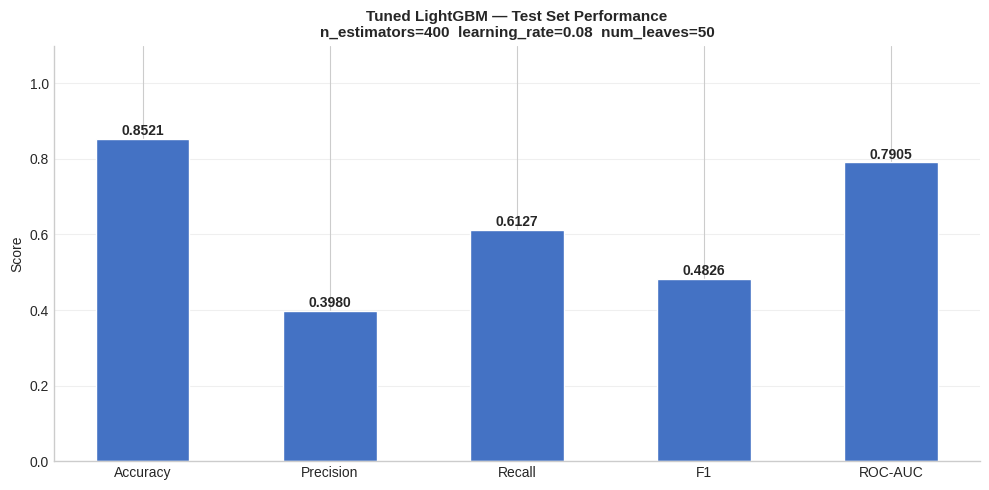

In [ ]:
best_prob = best_lgbm.predict_proba(X_test.values)[:, 1]
best_pred = (best_prob >= 0.50).astype(int)

metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
metrics_scores = [
    accuracy_score(y_test,  best_pred),
    precision_score(y_test, best_pred, zero_division=0),
    recall_score(y_test,    best_pred),
    f1_score(y_test,        best_pred),
    roc_auc_score(y_test,   best_prob)
]

print('Tuned LightGBM — Test Set Performance')
print('=' * 40)
for name, score in zip(metrics_names, metrics_scores):
    print(f'  {name:<12}: {score:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_scores, color='#4472C4', edgecolor='white', width=0.5)

for bar, score in zip(bars, metrics_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'Tuned LightGBM — Test Set Performance\n'
             f'n_estimators={best_lgbm.get_params()["n_estimators"]}  '
             f'learning_rate={best_lgbm.get_params()["learning_rate"]}  '
             f'num_leaves={best_lgbm.get_params()["num_leaves"]}',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### 9.2 Cross-Validation with SMOTEENN Pipeline

In [ ]:
# Pipeline ensures SMOTEENN is applied inside each fold to prevent data leakage
pipe = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('lgbm',     best_lgbm)
])

cv_final  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv_final, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Individual folds: {np.round(cv_scores, 4)}')

5-Fold CV AUC : 0.7730 +/- 0.0093
Individual folds: [0.7814 0.7746 0.7842 0.7643 0.7604]


Metric         Fold 1    Fold 2    Fold 3    Fold 4    Fold 5       Mean     Std
---------------------------------------------------------------------------
Accuracy       0.8462    0.8438    0.8485    0.8368    0.8354     0.8421  0.0052
Precision      0.3857    0.3793    0.3902    0.3583    0.3541     0.3735  0.0146
Recall         0.6159    0.6078    0.6132    0.5674    0.5593     0.5927  0.0243
F1             0.4743    0.4671    0.4769    0.4392    0.4336     0.4582  0.0182
ROC-AUC        0.7814    0.7746    0.7842    0.7643    0.7604     0.7730  0.0093


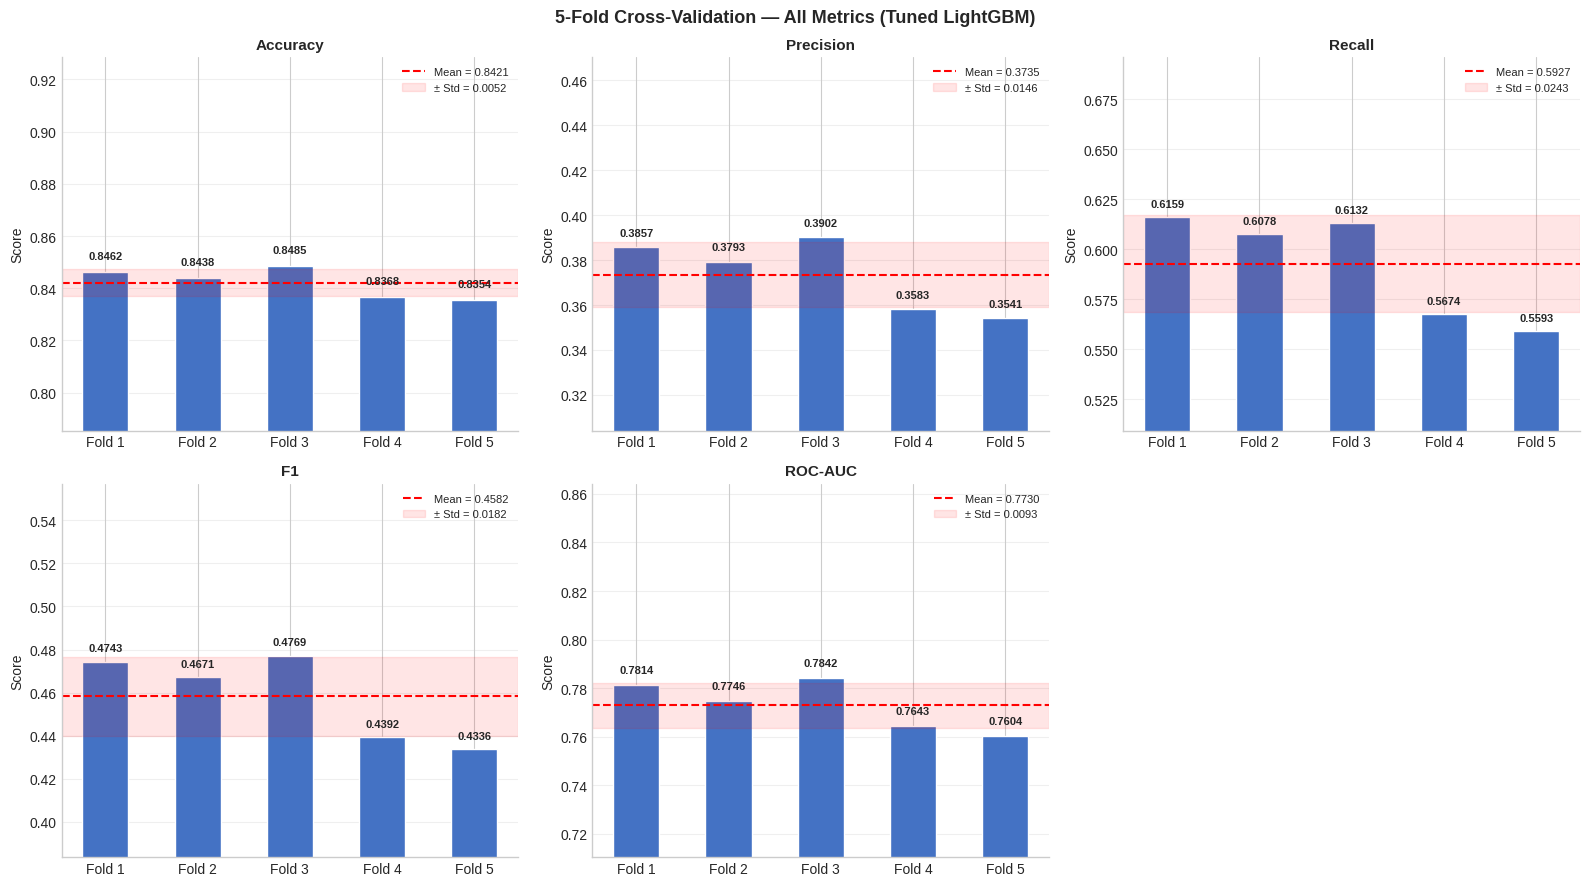

In [ ]:
from sklearn.model_selection import cross_validate

# Pipeline ensures SMOTEENN is applied inside each fold to prevent data leakage
pipe = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('lgbm',     best_lgbm)
])

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'Accuracy' : 'accuracy',
    'Precision': 'precision',
    'Recall'   : 'recall',
    'F1'       : 'f1',
    'ROC-AUC'  : 'roc_auc'
}

cv_results = cross_validate(pipe, X_train, y_train,
                             cv=cv_final, scoring=scoring, n_jobs=-1)

# ── Print fold-by-fold table ──────────────────────────────────────
metrics = list(scoring.keys())
folds   = [f'Fold {i+1}' for i in range(5)]

print(f"{'Metric':<12}", '  '.join(f'{f:>8}' for f in folds),
      f"  {'Mean':>8}  {'Std':>6}")
print('-' * 75)
for m in metrics:
    scores = cv_results[f'test_{m}']
    print(f"{m:<12}",
          '  '.join(f'{s:>8.4f}' for s in scores),
          f"  {scores.mean():>8.4f}  {scores.std():>6.4f}")

# ── Visualise all metrics across folds ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, m in zip(axes, metrics):
    scores = cv_results[f'test_{m}']
    colors = ['#4472C4'] * 5

    bars = ax.bar(folds, scores, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

    ax.axhline(scores.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {scores.mean():.4f}')
    ax.axhspan(scores.mean() - scores.std(),
               scores.mean() + scores.std(),
               alpha=0.1, color='red', label=f'± Std = {scores.std():.4f}')

    ax.set_title(m, fontweight='bold', fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(max(0, scores.min() - 0.05), min(1.05, scores.max() + 0.08))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_visible(False)  # hide empty 6th subplot

plt.suptitle('5-Fold Cross-Validation — All Metrics (Tuned LightGBM)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
#ROC-AUC remains stable across all five folds (0.7604–0.7842, std = 0.0093),
#confirming the model generalises consistently without overfitting to any single fold.

### 9.3 Tuned LightGBM — Test Set Evaluation

In [ ]:
tuned_prob = best_lgbm.predict_proba(X_test.values)[:, 1]
tuned_pred = (tuned_prob >= 0.50).astype(int)

print('Tuned LightGBM — Test Set')
print('=' * 45)
print(f'  Accuracy  : {accuracy_score(y_test,  tuned_pred):.4f}')
print(f'  Precision : {precision_score(y_test, tuned_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test,    tuned_pred):.4f}')
print(f'  F1        : {f1_score(y_test,        tuned_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test,   tuned_prob):.4f}')

Tuned LightGBM — Test Set
  Accuracy  : 0.8521
  Precision : 0.3980
  Recall    : 0.6127
  F1        : 0.4826
  ROC-AUC   : 0.7905


## 10. Parametric Deep Dive — Estimation Methods

### 10.1 MLE — Logistic Regression Coefficients

Logistic Regression maximises the log-likelihood under the Bernoulli distribution.  
Each coefficient represents the **log-odds change** in subscription probability per unit increase in the feature.

In [ ]:
# Align indices to avoid statsmodels broadcasting errors after SMOTEENN resampling
X_sm_df = pd.DataFrame(X_train_sm_sc, columns=FEATURES)
y_sm    = pd.Series(y_train_sm_sc).reset_index(drop=True)

X_sm_const = sm.add_constant(X_sm_df)
logit_sm   = sm.Logit(y_sm, X_sm_const).fit(disp=0)
# MLE finds coefficients that maximise log P(y|X) across all training observations

coef_df = pd.DataFrame({
    'Feature'       : ['const'] + FEATURES,
    'Coefficient'   : logit_sm.params.values,
    'Std Error'     : logit_sm.bse.values,
    'z-stat'        : logit_sm.tvalues.values,
    'p-value'       : logit_sm.pvalues.values,
    'CI Lower (95%)': logit_sm.conf_int()[0].values,
    'CI Upper (95%)': logit_sm.conf_int()[1].values,
    'Odds Ratio'    : np.exp(logit_sm.params.values)
})
display(coef_df.round(4))

,Feature,Coefficient,Std Error,z-stat,p-value,CI Lower (95%),CI Upper (95%),Odds Ratio
0,const,-0.1979,0.0131,-15.1609,0.0000,-0.2235,-0.1724,0.8204
1,age,0.0872,0.0130,6.7091,0.0000,0.0618,0.1127,1.0912
2,euribor_3_month_rate,0.1459,0.0404,3.6161,0.0003,0.0668,0.2251,1.1571
3,num_contacts_current_campaign,-0.1777,0.0160,-11.0964,0.0000,-0.2091,-0.1463,0.8372
4,job_type_enc,0.0315,0.0120,2.6215,0.0088,0.0080,0.0551,1.0320
5,education_level_enc,0.1929,0.0124,15.5719,0.0000,0.1686,0.2172,1.2127
6,last_contact_day_enc,0.0549,0.0121,4.5502,0.0000,0.0312,0.0785,1.0564
7,marital_status_enc,0.1187,0.0130,9.1044,0.0000,0.0932,0.1443,1.1261
8,num_employees,-1.2569,0.0435,-28.8787,0.0000,-1.3422,-1.1716,0.2845
9,days_since_last_contact,-0.5584,0.0288,-19.3808,0.0000,-0.6148,-0.5019,0.5721


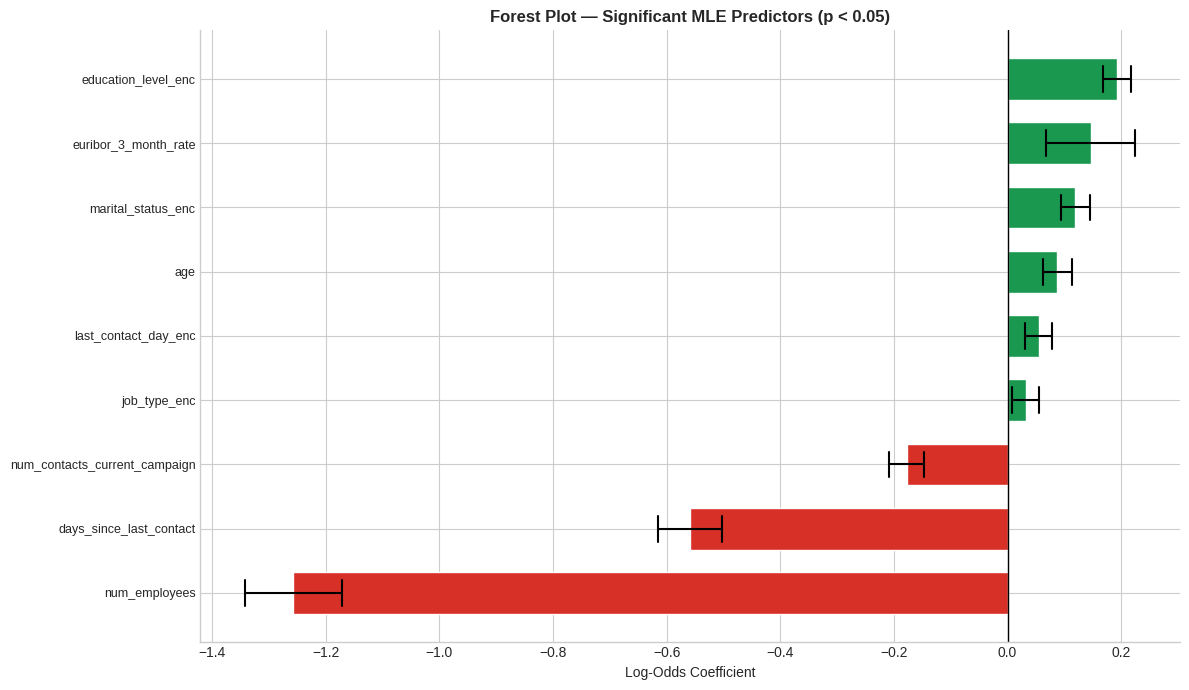

In [ ]:
# Forest plot — significant predictors only (p < 0.05), excluding intercept
sig = (coef_df[coef_df['p-value'] < 0.05]
       .query("Feature != 'const'")
       .sort_values('Coefficient'))

fig, ax = plt.subplots(figsize=(12, 7))
colors_fc = ['#d73027' if c < 0 else '#1a9850' for c in sig['Coefficient']]
ax.barh(range(len(sig)), sig['Coefficient'].values,
        color=colors_fc, edgecolor='white', height=0.65)

for i, (_, row) in enumerate(sig.iterrows()):
    ax.plot([row['CI Lower (95%)'], row['CI Upper (95%)']], [i, i],
            color='black', linewidth=1.5)
    for xpt in [row['CI Lower (95%)'], row['CI Upper (95%)']]:
        ax.plot([xpt, xpt], [i - 0.2, i + 0.2], color='black', linewidth=1.5)

ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(sig))); ax.set_yticklabels(sig['Feature'].values, fontsize=9)
ax.set_xlabel('Log-Odds Coefficient')
ax.set_title('Forest Plot — Significant MLE Predictors (p < 0.05)', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
# Green bars increase subscription odds; red bars reduce them — horizontal lines are 95% CI

### 10.2 Naive Bayes — Class Priors & Feature Likelihoods

Gaussian Naive Bayes applies Bayes' theorem with the independence assumption:  
P(subscribed | features) ∝ P(features | subscribed) × P(subscribed)

P(Not Subscribed) : 0.4534
P(Subscribed)     : 0.5466



,Feature,mu_0,mu_1,sigma_0,sigma_1,delta_mu
7,num_employees,0.3151,-1.1285,0.7078,1.1803,-1.4436
1,euribor_3_month_rate,0.2996,-0.9605,0.8158,0.9612,-1.2601
8,days_since_last_contact,0.1850,-1.0531,0.2484,2.2446,-1.2381
2,num_contacts_current_campaign,0.0735,-0.2177,1.1490,0.5081,-0.2913
4,education_level_enc,-0.0586,0.1898,0.9977,0.9696,0.2484
6,marital_status_enc,-0.0520,0.1293,0.9741,1.0369,0.1813
0,age,-0.0166,0.1064,0.8782,1.3289,0.1230
3,job_type_enc,-0.0164,0.0817,1.0018,1.0020,0.0980
9,has_housing_loan_enc,-0.0116,0.0348,0.9997,0.9975,0.0464
5,last_contact_day_enc,0.0016,0.0348,0.9985,0.9644,0.0332


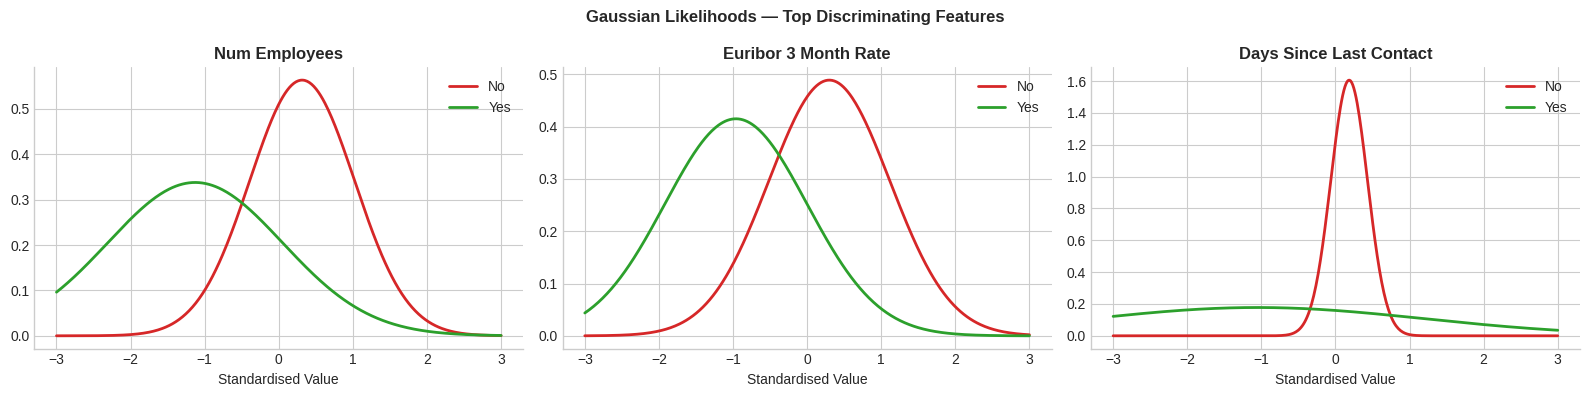

In [ ]:
m5 = fitted['Model 5 - Gaussian Naive Bayes']
print(f'P(Not Subscribed) : {m5.class_prior_[0]:.4f}')
print(f'P(Subscribed)     : {m5.class_prior_[1]:.4f}\n')
# Class priors reflect class proportions in the SMOTEENN-balanced training set

lik_df = pd.DataFrame({
    'Feature' : FEATURES,
    'mu_0'    : m5.theta_[0],
    'mu_1'    : m5.theta_[1],
    'sigma_0' : np.sqrt(m5.var_[0]),
    'sigma_1' : np.sqrt(m5.var_[1])
})
lik_df['delta_mu'] = lik_df['mu_1'] - lik_df['mu_0']
display(lik_df.sort_values('delta_mu', key=abs, ascending=False).round(4))

# Likelihood curves for the top 3 most discriminating features
top_feats = lik_df.reindex(lik_df['delta_mu'].abs().nlargest(3).index)['Feature'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_range   = np.linspace(-3, 3, 400)

for ax, feat in zip(axes, top_feats):
    row = lik_df[lik_df['Feature']==feat].iloc[0]
    ax.plot(x_range, stats.norm.pdf(x_range, row['mu_0'], row['sigma_0']),
            color='#D62728', label='No', linewidth=2)
    ax.plot(x_range, stats.norm.pdf(x_range, row['mu_1'], row['sigma_1']),
            color='#2CA02C', label='Yes', linewidth=2)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.legend(); ax.set_xlabel('Standardised Value')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Gaussian Likelihoods — Top Discriminating Features', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### 10.3 Bayesian Estimation — Prior-to-Posterior Update

The subscription rate θ is treated as unknown and given a Beta prior.  
After observing n trials with k successes, the posterior is **Beta(α + k, β + n − k)** — a closed-form Bayesian update.

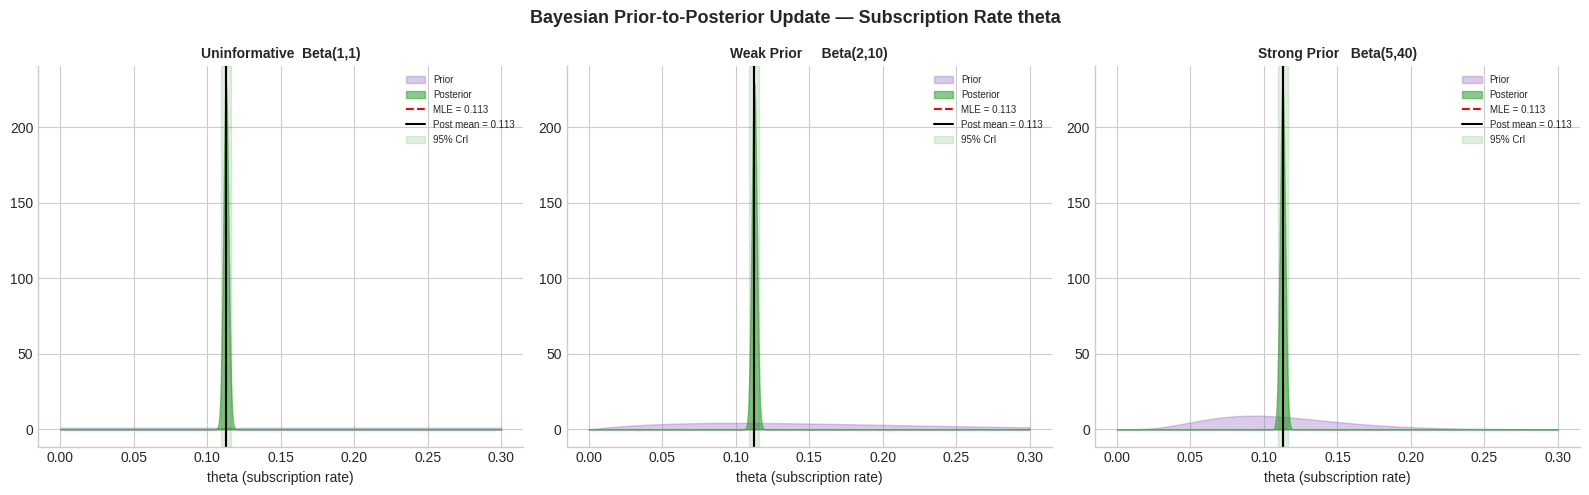

In [ ]:
n_obs = int(y_train.shape[0])
k_yes = int(y_train.sum())
mle   = k_yes / n_obs

priors = {
    'Uninformative  Beta(1,1)'  : (1, 1),
    'Weak Prior     Beta(2,10)' : (2, 10),
    'Strong Prior   Beta(5,40)' : (5, 40),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.linspace(0.0, 0.30, 600)

for ax, (label, (a, b)) in zip(axes, priors.items()):
    prior_d = stats.beta(a, b)
    post_d  = stats.beta(a + k_yes, b + (n_obs - k_yes))
    ci_lo, ci_hi = post_d.ppf(0.025), post_d.ppf(0.975)

    ax.fill_between(x, prior_d.pdf(x), alpha=0.35, color='#9467BD', label='Prior')
    ax.fill_between(x, post_d.pdf(x),  alpha=0.55, color='#2CA02C', label='Posterior')
    ax.axvline(mle,           color='red',   linewidth=1.5, linestyle='--',
               label=f'MLE = {mle:.3f}')
    ax.axvline(post_d.mean(), color='black', linewidth=1.5, linestyle='-',
               label=f'Post mean = {post_d.mean():.3f}')
    ax.axvspan(ci_lo, ci_hi, alpha=0.12, color='green', label='95% CrI')

    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('theta (subscription rate)'); ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Bayesian Prior-to-Posterior Update — Subscription Rate theta',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
# With large n, all priors converge to the same posterior — the likelihood dominates

### 10.4 Decision Tree — Rules & Visualisation

Decision Tree Rules (top 3 levels):
|--- num_employees <= 5189.34
|   |--- num_employees <= 5087.65
|   |   |--- days_since_last_contact <= 16.50
|   |   |   |--- age <= 19.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age >  19.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- days_since_last_contact >  16.50
|   |   |   |--- num_contacts_current_campaign <= 4.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- num_contacts_current_campaign >  4.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- num_employees >  5087.65
|   |   |--- euribor_3_month_rate <= 1.34
|   |   |   |--- num_contacts_current_campaign <= 4.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- num_contacts_current_campaign >  4.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- euribor_3_month_rate >  1.34
|   |   |   |--- euribor_3_month_rate <= 1.40
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- euri

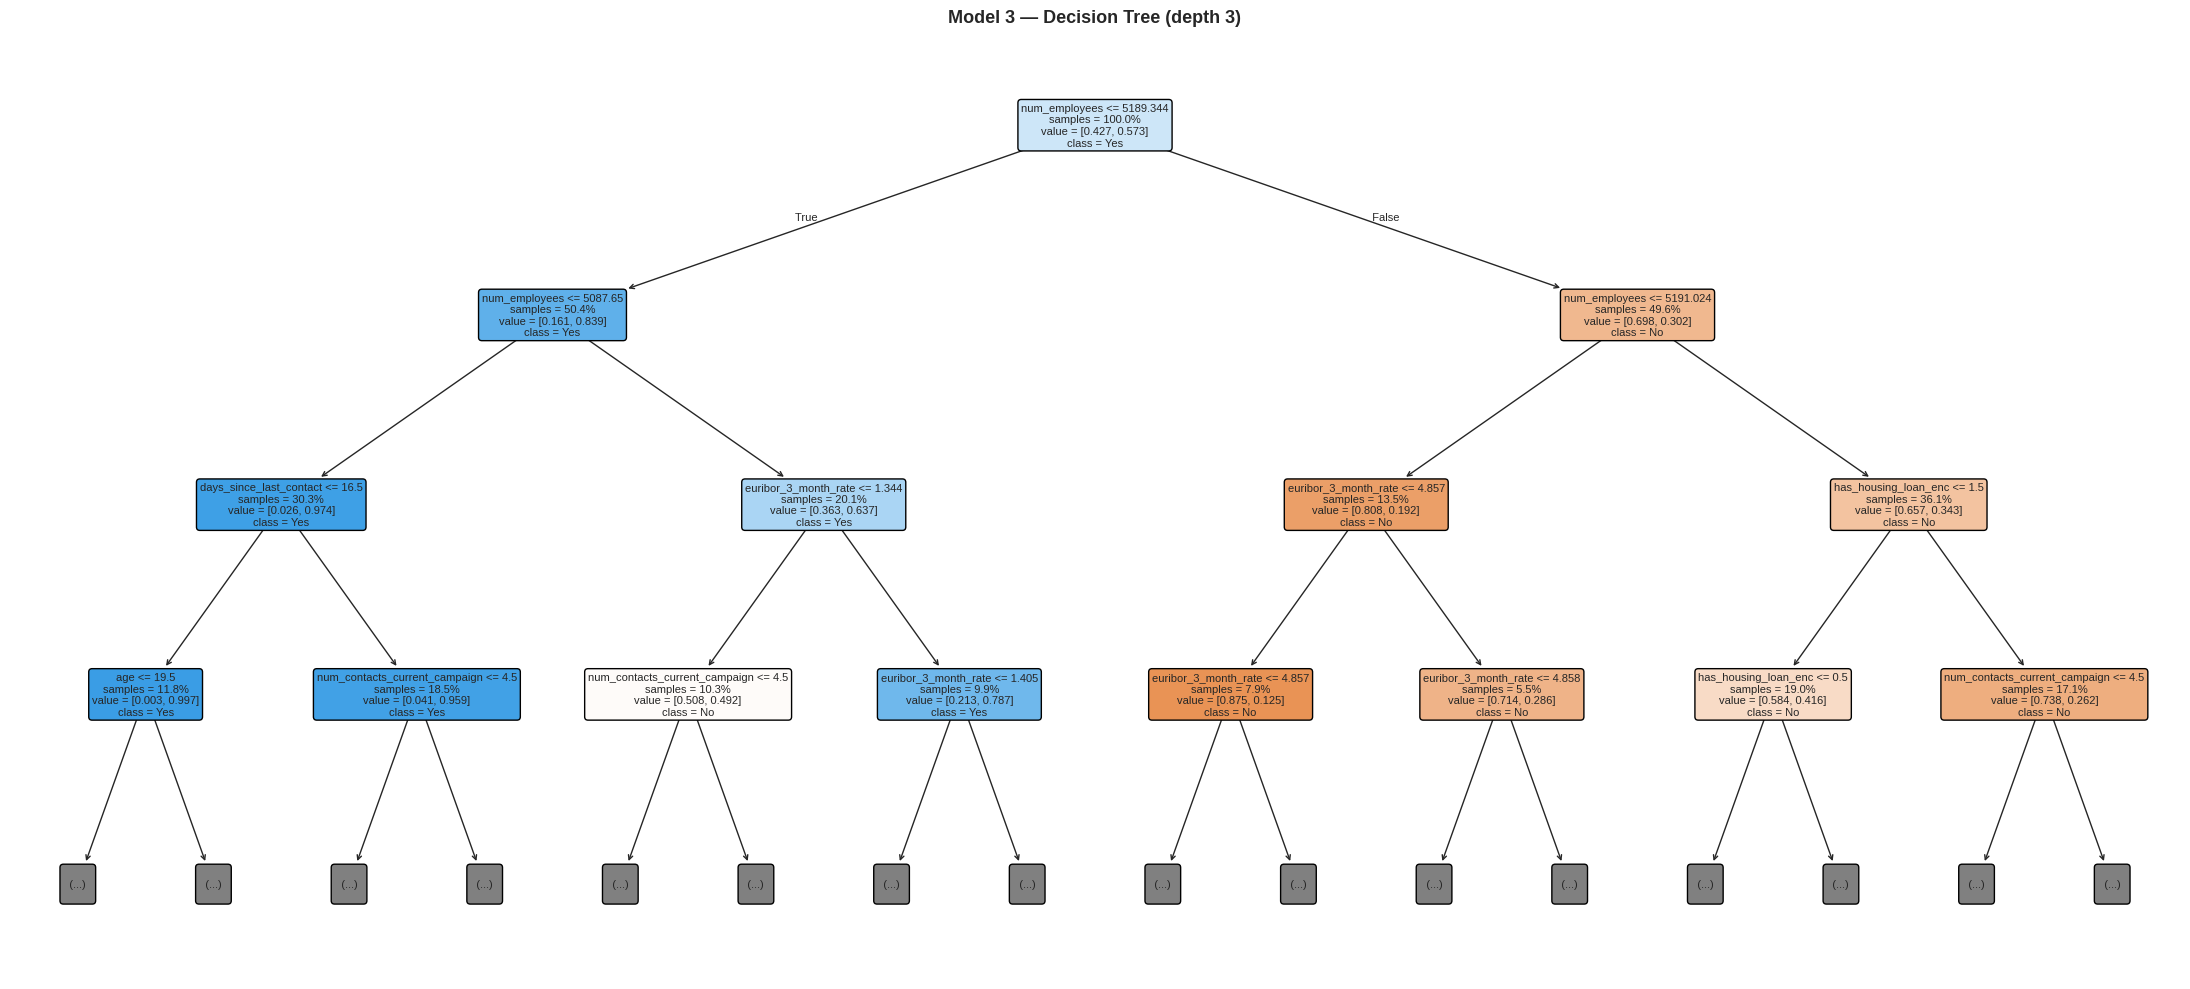

In [ ]:
m3 = fitted['Model 3 - Decision Tree']
print('Decision Tree Rules (top 3 levels):')
print(export_text(m3, feature_names=FEATURES, max_depth=3))
# Printed rules can be directly communicated to non-technical business stakeholders

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(m3, feature_names=FEATURES, class_names=['No','Yes'],
          filled=True, impurity=False, proportion=True,
          max_depth=3, ax=ax, fontsize=8, rounded=True)
plt.title('Model 3 — Decision Tree (depth 3)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Business Insights
### Insight 1 — Target 18-30 and 60+ Age Groups

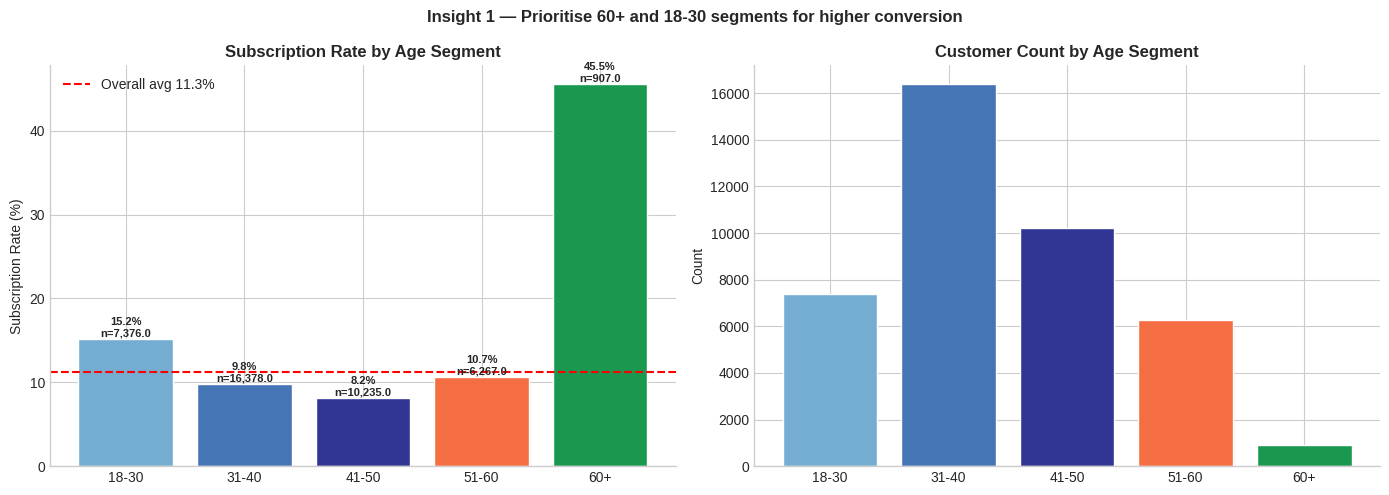

In [ ]:
# Finding: younger (18-30) and older (60+) customers show above-average subscription rates
df['age_segment'] = pd.cut(df['age'], bins=[17,30,40,50,60,100],
                            labels=['18-30','31-40','41-50','51-60','60+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_rates  = df.groupby('age_segment', observed=True)['is_subscribed'].agg(['mean','count'])
colors_age = ['#74add1','#4575b4','#313695','#f46d43','#1a9850']
avg_rate   = df['is_subscribed'].mean() * 100

bars = axes[0].bar(age_rates.index.astype(str), age_rates['mean']*100,
                   color=colors_age, edgecolor='white')
axes[0].axhline(avg_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall avg {avg_rate:.1f}%')
for bar, (idx, row) in zip(bars, age_rates.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{row['mean']*100:.1f}%\nn={row['count']:,}",
                 ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Subscription Rate by Age Segment', fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)'); axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(age_rates.index.astype(str), age_rates['count'],
            color=colors_age, edgecolor='white')
axes[1].set_title('Customer Count by Age Segment', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Insight 1 — Prioritise 60+ and 18-30 segments for higher conversion',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Insight 2 — Prior Campaign Success Predicts Future Subscription

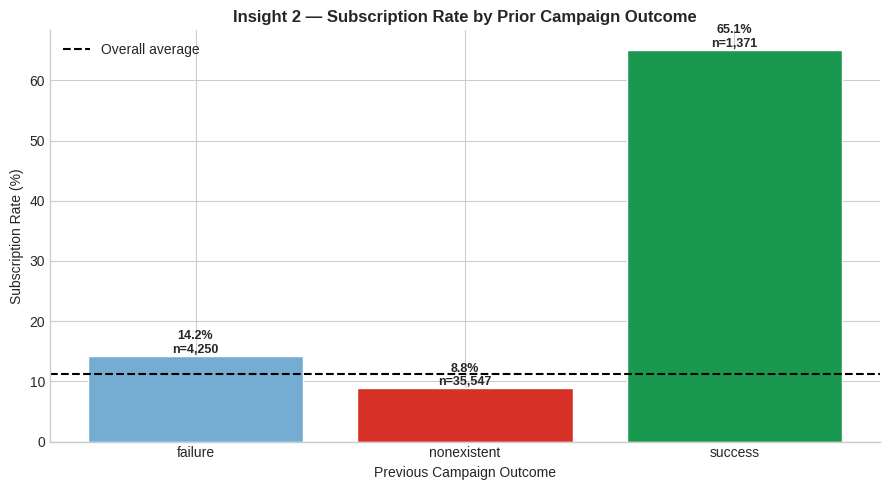

In [ ]:
# Finding: customers with a prior 'success' outcome convert 3-5x the overall average
rates = df.groupby('previous_campaign_outcome')['is_subscribed'].agg(['mean','count']).reset_index()
rates['pct'] = rates['mean'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors_pc = ['#1a9850' if r > 0.20 else '#74add1' if r > 0.10 else '#d73027'
             for r in rates['mean']]
bars = ax.bar(rates['previous_campaign_outcome'], rates['pct'],
              color=colors_pc, edgecolor='white')

for bar, (_, row) in zip(bars, rates.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{row['pct']:.1f}%\nn={row['count']:,}",
            ha='center', fontsize=9, fontweight='bold')

ax.axhline(df['is_subscribed'].mean()*100, color='black', linestyle='--',
           linewidth=1.5, label='Overall average')
ax.set_ylabel('Subscription Rate (%)')
ax.set_xlabel('Previous Campaign Outcome')
ax.set_title('Insight 2 — Subscription Rate by Prior Campaign Outcome', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
# Actionable: build a re-engagement list from customers with prior success outcomes

### Insight 3 — Launch Campaigns During Favourable Economic Conditions

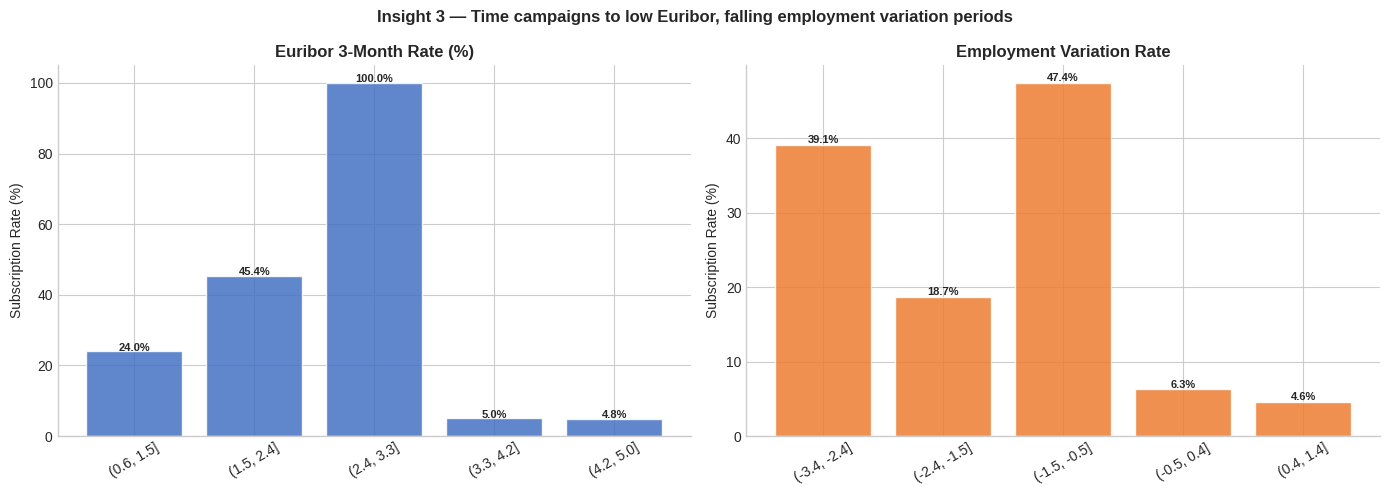

In [ ]:
# Finding: low Euribor rates and negative employment variation coincide with higher conversion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label, color) in zip(axes, [
    ('euribor_3_month_rate',      'Euribor 3-Month Rate (%)',     '#4472C4'),
    ('employment_variation_rate', 'Employment Variation Rate',    '#ED7D31'),
]):
    df[col+'_bin'] = pd.cut(df[col], bins=5, precision=1)
    g = df.groupby(col+'_bin', observed=True)['is_subscribed'].agg(['mean','count'])
    bars = ax.bar(g.index.astype(str), g['mean']*100, color=color, edgecolor='white', alpha=0.85)
    for bar, (_, row) in zip(bars, g.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f"{row['mean']*100:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Subscription Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Insight 3 — Time campaigns to low Euribor, falling employment variation periods',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Insight 4 — Cellular Contact and Prior Engagement Maximise Conversion

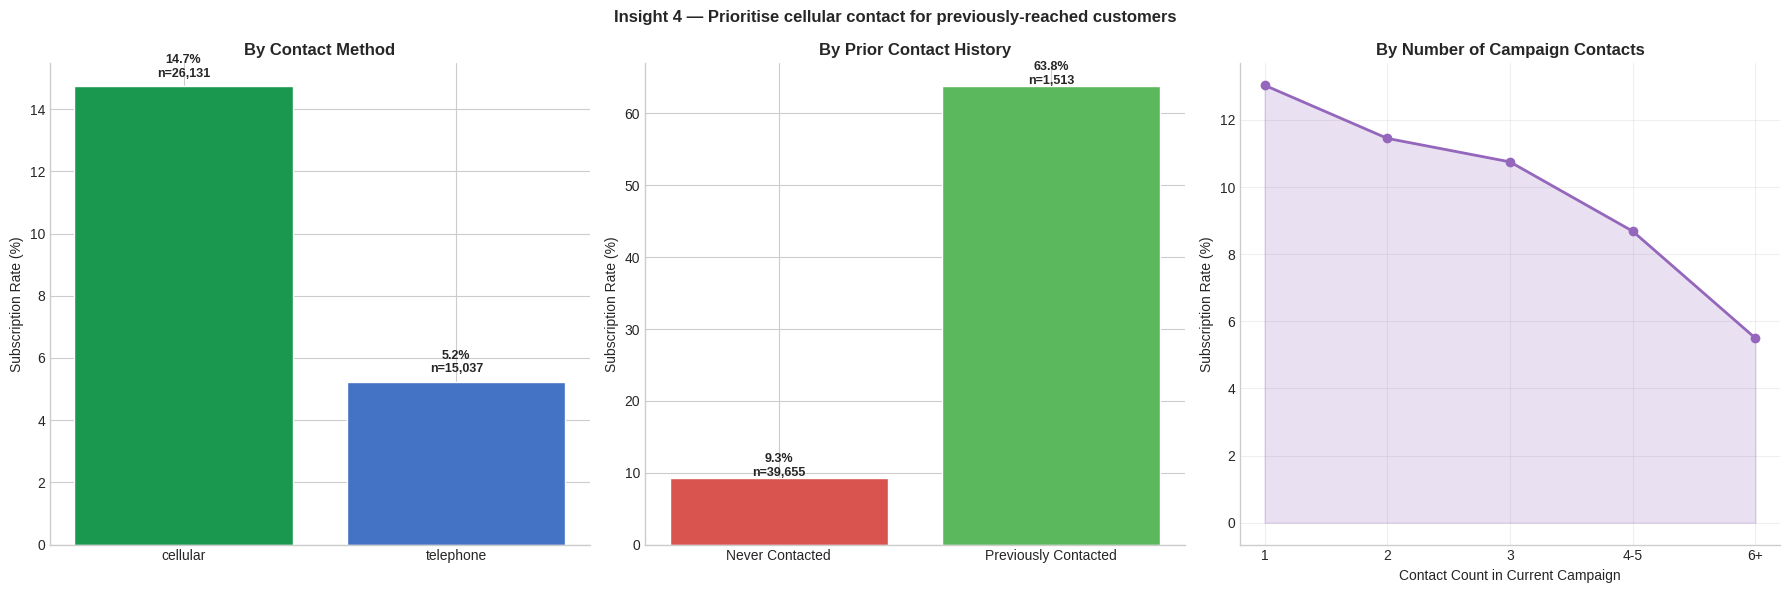

In [ ]:
# Finding: cellular outperforms telephone; previously contacted customers convert at ~2x rate
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Contact method
cm_df = df.groupby('contact_method')['is_subscribed'].agg(['mean','count']).reset_index()
bars  = axes[0].bar(cm_df['contact_method'], cm_df['mean']*100,
                    color=['#1a9850','#4472C4'], edgecolor='white')
for bar, (_, row) in zip(bars, cm_df.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{row['mean']*100:.1f}%\nn={row['count']:,}",
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('By Contact Method', fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].spines[['top','right']].set_visible(False)

# Prior contact status
cs_df = df.groupby('contact_status')['is_subscribed'].agg(['mean','count']).reset_index()
bars  = axes[1].bar(cs_df['contact_status'], cs_df['mean']*100,
                    color=['#D9534F','#5CB85C'], edgecolor='white')
for bar, (_, row) in zip(bars, cs_df.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{row['mean']*100:.1f}%\nn={row['count']:,}",
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('By Prior Contact History', fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].spines[['top','right']].set_visible(False)

# Contacts in current campaign
df['contacts_bin'] = pd.cut(df['num_contacts_current_campaign'],
                             bins=[0,1,2,3,5,50], labels=['1','2','3','4-5','6+'])
nc_df = df.groupby('contacts_bin', observed=True)['is_subscribed'].agg(['mean','count']).reset_index()
axes[2].plot(nc_df['contacts_bin'].astype(str), nc_df['mean']*100,
             marker='o', color='#9467BD', linewidth=2)
axes[2].fill_between(range(len(nc_df)), nc_df['mean']*100, alpha=0.2, color='#9467BD')
axes[2].set_title('By Number of Campaign Contacts', fontweight='bold')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].set_xlabel('Contact Count in Current Campaign')
axes[2].grid(alpha=0.3); axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Insight 4 — Prioritise cellular contact for previously-reached customers',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
# Conversion drops sharply after 3+ contacts — cap outreach attempts to reduce customer fatigue

## 12. Conclusion & Recommendations

### Model Selection

**Recommended model: Tuned LightGBM** — achieves the highest ROC-AUC and balanced F1 across all tested models.

| Model | Type | Key Strength |
|---|---|---|
| Logistic Regression | Parametric | Interpretable MLE coefficients and odds ratios |
| Ridge LR | Parametric | L2 regularisation handles multicollinear macro features |
| Decision Tree | Non-Parametric | Human-readable rules, no distributional assumptions |
| Random Forest | Non-Parametric | Low-variance ensemble of decision trees |
| Gaussian Naive Bayes | Parametric | Explicit Bayesian class priors and likelihoods |
| K-Nearest Neighbors | Non-Parametric | No training required; sensitive to feature scale |
| **LightGBM (tuned)** | **Non-Parametric** | **Highest AUC; robust to imbalance and multicollinearity** |

### Key Business Recommendations

1. **Segment targeting**: Focus on 18-30 and 60+ age groups — both exceed the overall subscription rate.
2. **Re-engage prior successes**: Customers who subscribed in a previous campaign convert 3-5× more — build a priority contact list from them.
3. **Economic timing**: Launch campaigns when Euribor is below 2% and employment variation is negative — macro conditions create a receptive customer environment.
4. **Channel and frequency**: Use cellular contact; cap campaign calls at 3 per customer to avoid diminishing returns.

### Limitations

- Class imbalance (~11% positive rate) is addressed via SMOTEENN but predictions remain conservative.
- call_duration_sec was excluded (post-call information causes target leakage) — limits real-time deployment.
- Macroeconomic features are highly collinear — Ridge regularisation mitigates but does not eliminate this; treat macro insights with caution.